# Lab 7- Data Analysis


## Exercise 1: Reading

### HiggsML
In 2014, some of my colleagues from the ATLAS experiment put together a Higgs Machine Learning Challenge, which was hosted on [Kaggle](https://www.kaggle.com). Please read sections 1 and 3 (skip/skim 2) of [The HiggsML Technical Documentation](https://higgsml.lal.in2p3.fr/files/2014/04/documentation_v1.8.pdf). 

Kaggle is a platform for data science competitions, with cash awards for winners. Kaggle currently hosts over 50,000 public datasets and associated competitions. Later in the course we will look at a variety of problems hosted on Kaggle and similar platforms. 

### SUSY Dataset

For the next few labs we will use datasets used in the [first paper on Deep Learning in High Energy physics](https://arxiv.org/pdf/1402.4735.pdf). Please read up to the "Deep Learning" section (end of page 5). This paper demonstrates that Deep Neural Networks can learn from raw data the features that are typically used by physicists for searches for exotics particles. The authors provide the data they used for this paper. They considered two benchmark scenarios: Higgs and SUSY.

## Exercise 2: Download SUSY Dataset

The information about the dataset can be found at the [UCI Machine Learning Repository](https://archive.ics.uci.edu/ml/index.php). We'll start with the [SUSY Dataset](https://archive.ics.uci.edu/ml/datasets/SUSY). 

### Download
In a terminal, download the data directly from the source and then decompress it. For example:

* To download:
    * On Mac OS: 
    `curl http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz > SUSY.csv.gz`

    * In linux:
    `wget http://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz`

* To uncompress:
`gunzip SUSY.csv.gz`

Because I am working in Jupyter on Windows, I use Python below instead of `gunzip`. This avoids the command-line problem and keeps the download/decompression steps in the notebook.


In [1]:
import os
import gzip
import shutil
import urllib.request

# I keep the file names in variables so I only have to change them in one place if needed.
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00279/SUSY.csv.gz"
gz_file = "SUSY.csv.gz"
csv_file = "SUSY.csv"

# I only download the compressed file if it is not already in this folder.
# This prevents me from downloading the large file again every time I rerun the notebook.
if not os.path.exists(gz_file):
    urllib.request.urlretrieve(url, gz_file)
    print("Downloaded", gz_file)
else:
    print(gz_file, "already exists")

# I only decompress the file if the CSV is missing.
# The .gz file is compressed, so Jupyter cannot open it like a normal CSV.
if not os.path.exists(csv_file):
    with gzip.open(gz_file, "rb") as f_in:
        with open(csv_file, "wb") as f_out:
            shutil.copyfileobj(f_in, f_out)
    print("Created", csv_file)
else:
    print(csv_file, "already exists")


SUSY.csv.gz already exists
SUSY.csv already exists


The data is provided as a comma separated file. I preview only the first few rows first so I can check that the file loaded correctly before doing larger work.

In [2]:
import pandas as pd

# I preview the first five rows without loading the whole dataset yet.
pd.read_csv("SUSY.csv", header=None, nrows=5)


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


## Reducing the dataset

This is a rather large dataset. If you have trouble loading it, we can easily make a new file with less data.

Here I check the file size and then create a smaller version for the rest of the lab.

In [3]:
# I check the file sizes in Python so this works on Windows too.
for file in ["SUSY.csv.gz", "SUSY.csv", "SUSY-small.csv"]:
    if os.path.exists(file):
        size_mb = os.path.getsize(file) / (1024**2)
        print(f"{file}: {size_mb:.1f} MB")
    else:
        print(file, "not found yet")


SUSY.csv.gz: 359.8 MB
SUSY.csv: 2279.5 MB
SUSY-small.csv: 228.0 MB


The full file has 5 million rows, so I create a smaller file with the first 500,000 rows. This is enough for the plotting and analysis in this lab.

In [4]:
small_file = "SUSY-small.csv"
n_small = 500_000

# I create the smaller file only if it does not already exist.
# This avoids repeating a slow file-writing step every time I rerun the notebook.
if not os.path.exists(small_file):
    with open("SUSY.csv", "r") as f_in:
        with open(small_file, "w") as f_out:
            for i, line in enumerate(f_in):
                if i >= n_small:
                    break
                f_out.write(line)
    print("Created", small_file)
else:
    print(small_file, "already exists")

# I check the smaller file by reading only the first few rows.
pd.read_csv(small_file, header=None, nrows=5)


SUSY-small.csv already exists


,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


Use this smaller file for the rest of the lab to make the notebook run faster.

### First Look

Each row represents a LHC collision event. Each column contains some observable from that event. The variable names are ([based on documentation](https://archive.ics.uci.edu/ml/datasets/SUSY)):

In [5]:
VarNames=["signal", "l_1_pT", "l_1_eta","l_1_phi", "l_2_pT", 
          "l_2_eta", "l_2_phi", "MET", "MET_phi", "MET_rel",
          "axial_MET", "M_R", "M_TR_2", "R", "MT2", "S_R", "M_Delta_R",
          "dPhi_r_b", "cos_theta_r1"]

Some of these variables represent the "raw" kinematics of the observed final state particles, while others are "features" that are derived from these raw quantities:

In [6]:
RawNames = ["l_1_pT", "l_1_eta", "l_1_phi", "l_2_pT", "l_2_eta",
            "l_2_phi", "MET", "MET_phi"]

# I keep the high-level feature names in the same order as VarNames.
# This is better than using set(), because set() can change the order.
FeatureNames = [name for name in VarNames[1:] if name not in RawNames]


In [7]:
RawNames

['l_1_pT',
 'l_1_eta',
 'l_1_phi',
 'l_2_pT',
 'l_2_eta',
 'l_2_phi',
 'MET',
 'MET_phi']

In [8]:
FeatureNames

['MET_rel',
 'axial_MET',
 'M_R',
 'M_TR_2',
 'R',
 'MT2',
 'S_R',
 'M_Delta_R',
 'dPhi_r_b',
 'cos_theta_r1']

We will use pandas to read in the file, and matplotlib to make plots. The following ensures pandas is installed and sets everything up:

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline

Now we can read the data into a pandas dataframe:

In [10]:
# I use the smaller dataset for the rest of the lab so the plots run faster.
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype="float64", names=VarNames)


You can see the data in Jupyter by just evaluating the dataframe:

In [11]:
# I use head() instead of displaying the whole dataframe.
# This lets me check the columns without printing 500,000 rows.
df.head()


,signal,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
0,0.0,0.972861,0.653855,1.176225,1.157156,-1.739873,-0.874309,0.567765,-0.175000,0.810061,-0.252552,1.921887,0.889637,0.410772,1.145621,1.932632,0.994464,1.367815,0.040714
1,1.0,1.667973,0.064191,-1.225171,0.506102,-0.338939,1.672543,3.475464,-1.219136,0.012955,3.775174,1.045977,0.568051,0.481928,0.000000,0.448410,0.205356,1.321893,0.377584
2,1.0,0.444840,-0.134298,-0.709972,0.451719,-1.613871,-0.768661,1.219918,0.504026,1.831248,-0.431385,0.526283,0.941514,1.587535,2.024308,0.603498,1.562374,1.135454,0.180910
3,1.0,0.381256,-0.976145,0.693152,0.448959,0.891753,-0.677328,2.033060,1.533041,3.046260,-1.005285,0.569386,1.015211,1.582217,1.551914,0.761215,1.715464,1.492257,0.090719
4,1.0,1.309996,-0.690089,-0.676259,1.589283,-0.693326,0.622907,1.087562,-0.381742,0.589204,1.365479,1.179295,0.968218,0.728563,0.000000,1.083158,0.043429,1.154854,0.094859


The first column stores the "truth" label of whether an event was signal or not. Pandas makes it easy to create dataframes that store only the signal or background events:

In [12]:
# I split the data into signal and background events.
# The signal column is the truth label: 1 means signal, and 0 means background.
df_sig = df[df["signal"] == 1]
df_bkg = df[df["signal"] == 0]

print("Signal rows:", len(df_sig))
print("Background rows:", len(df_bkg))


Signal rows: 229245
Background rows: 270755


The following example plots the signal and background distributions of every variable. Note that we use VarNames[1:] to skip the first variable, which was the true label.

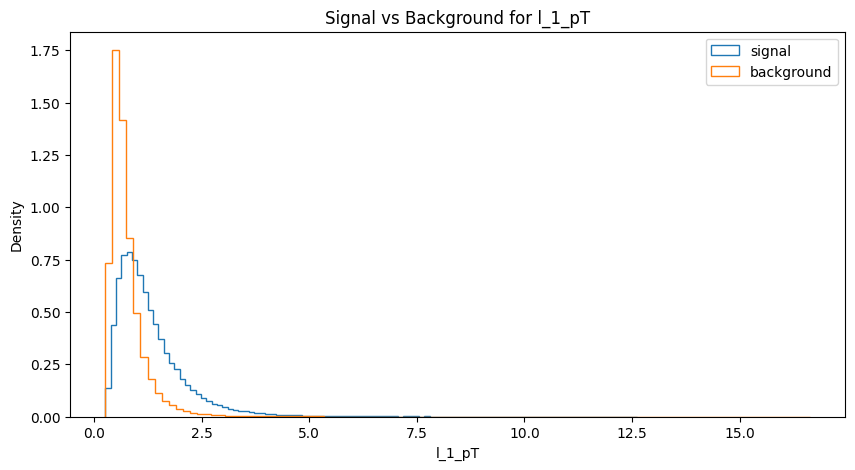

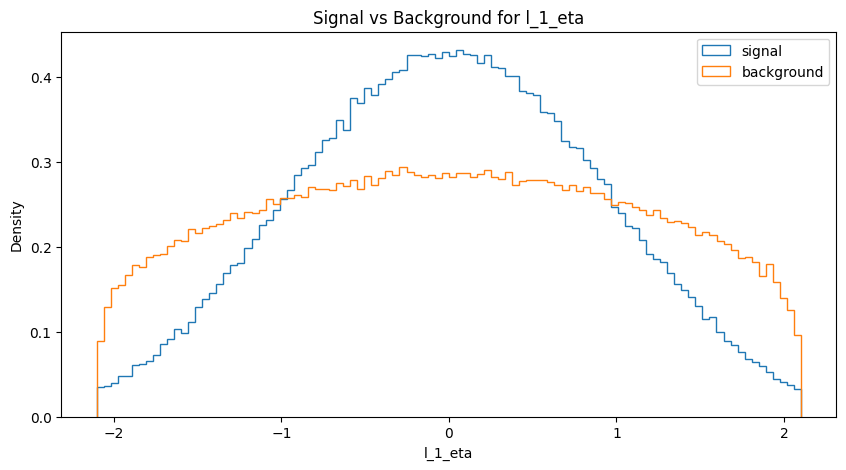

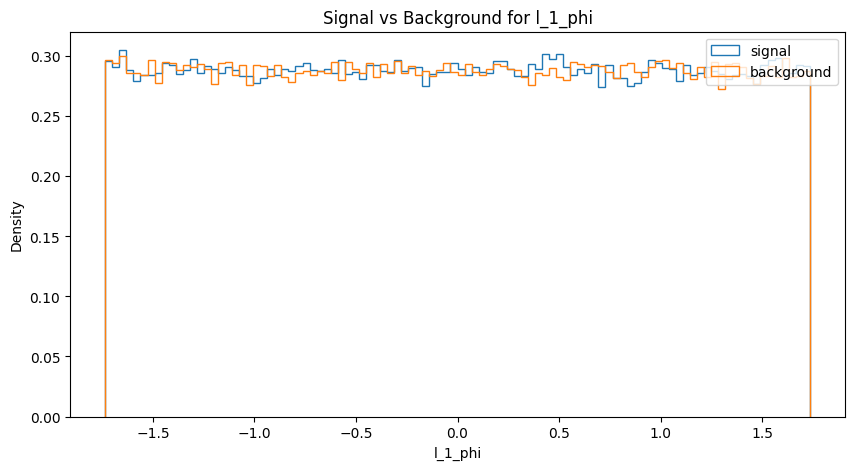

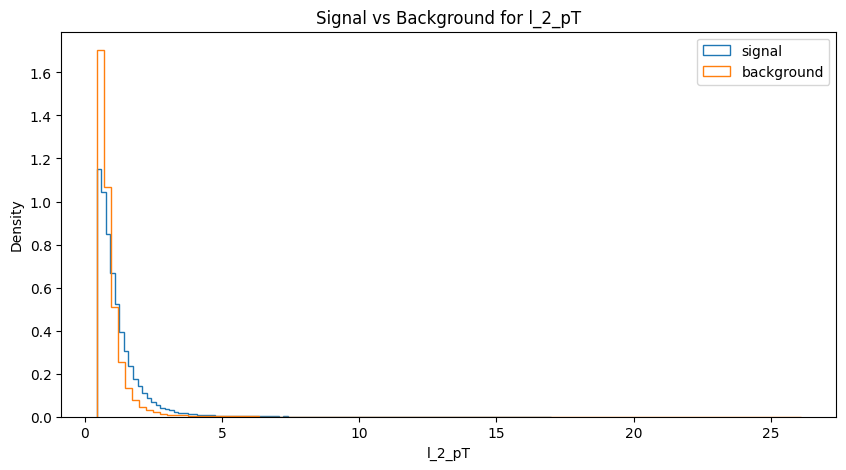

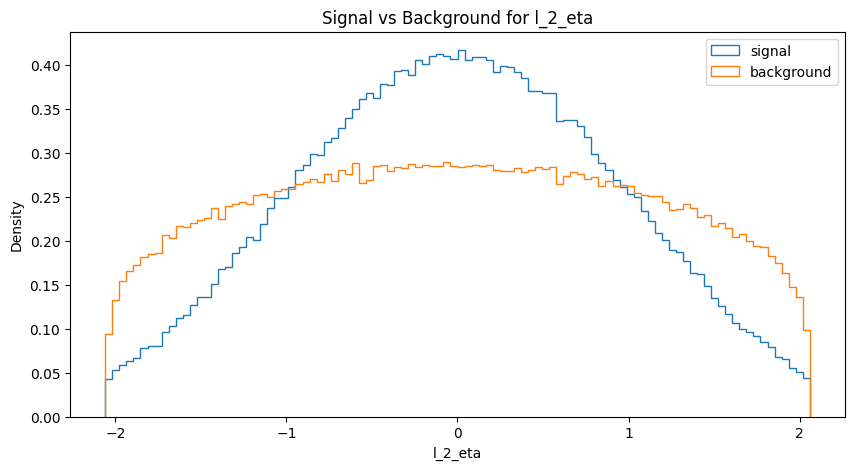

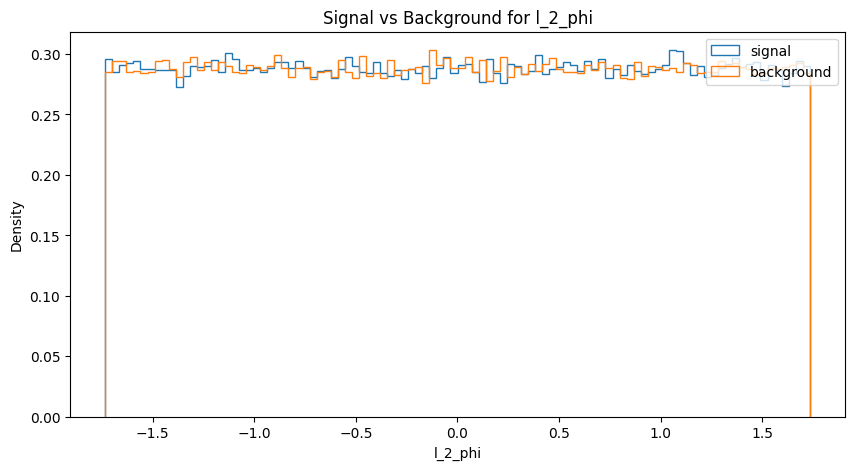

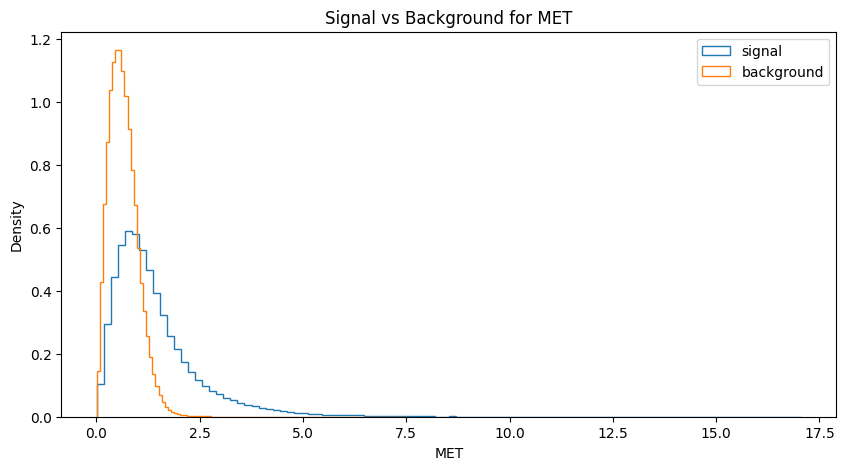

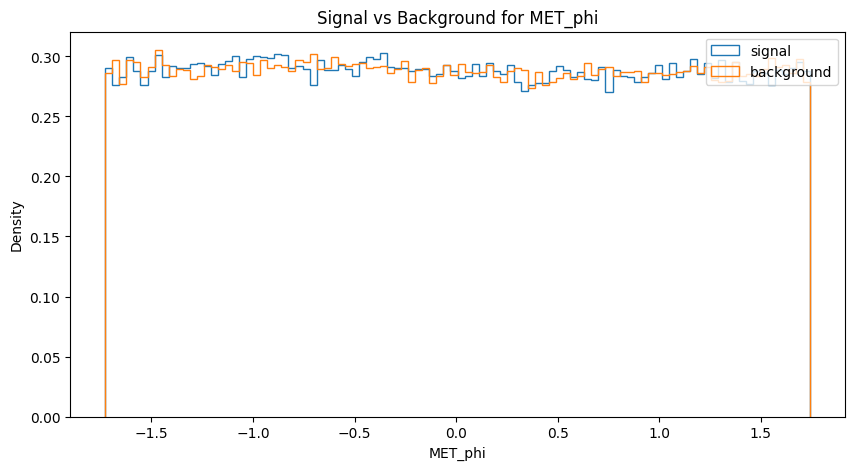

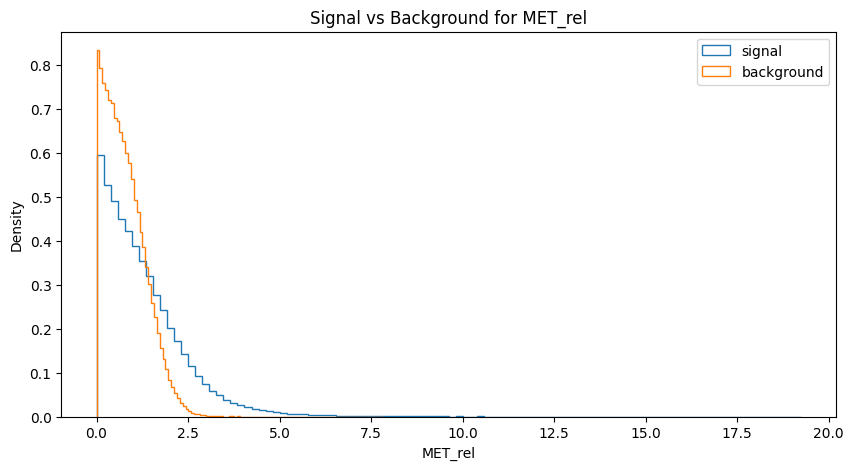

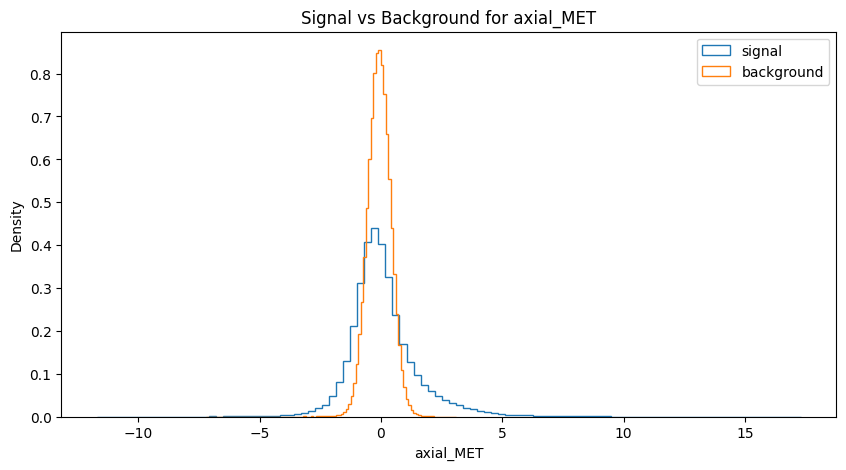

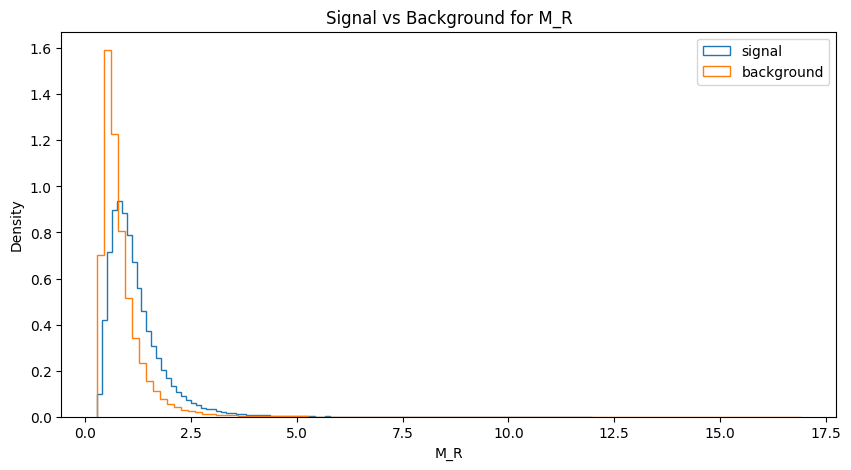

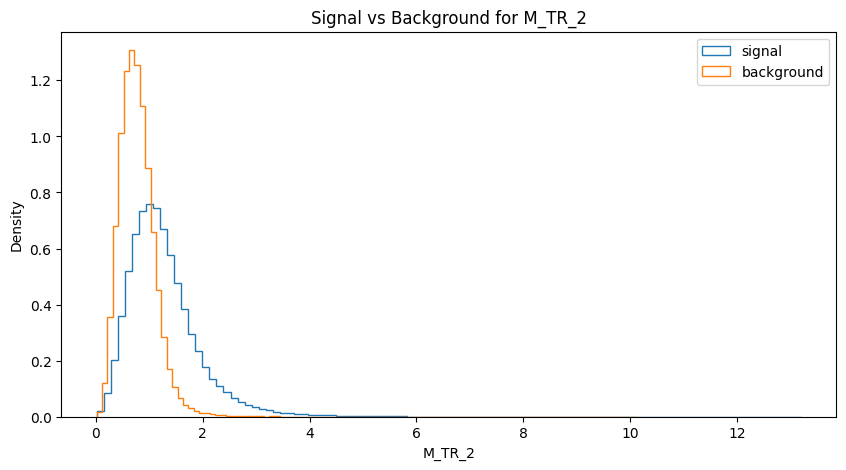

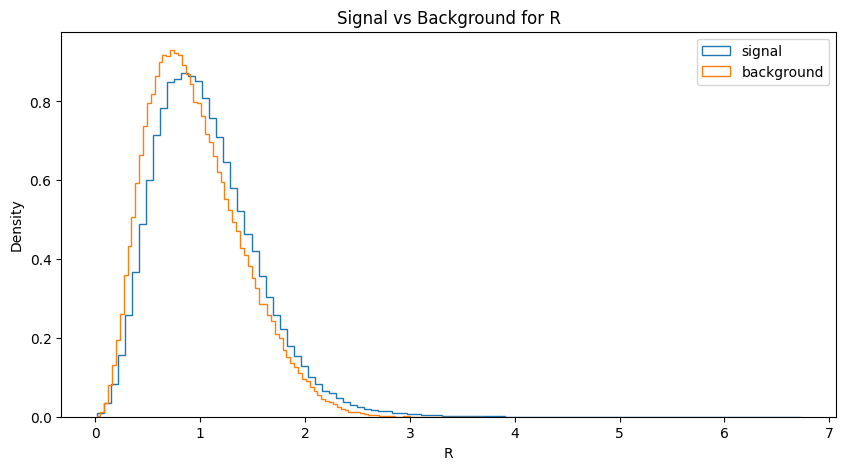

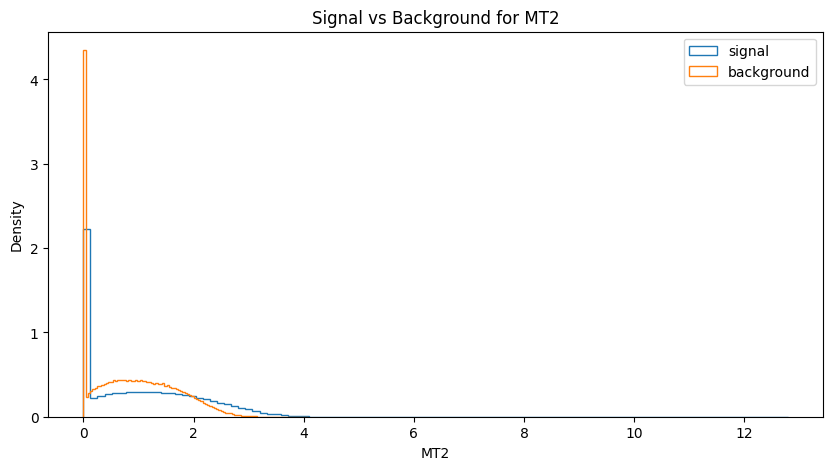

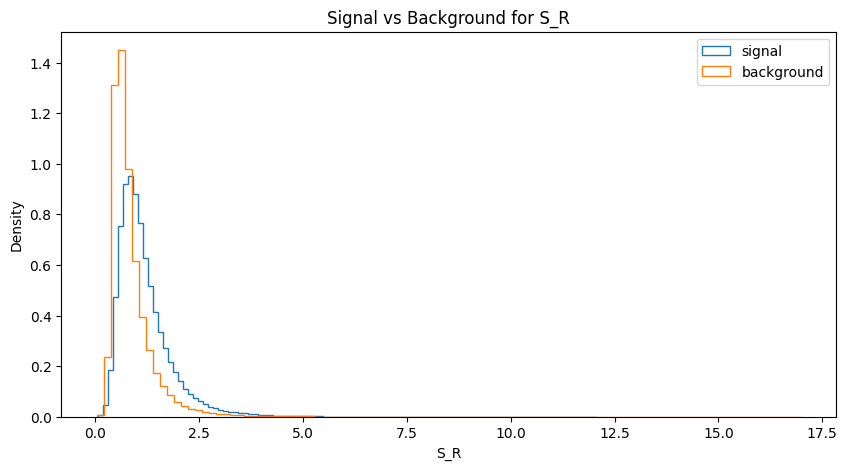

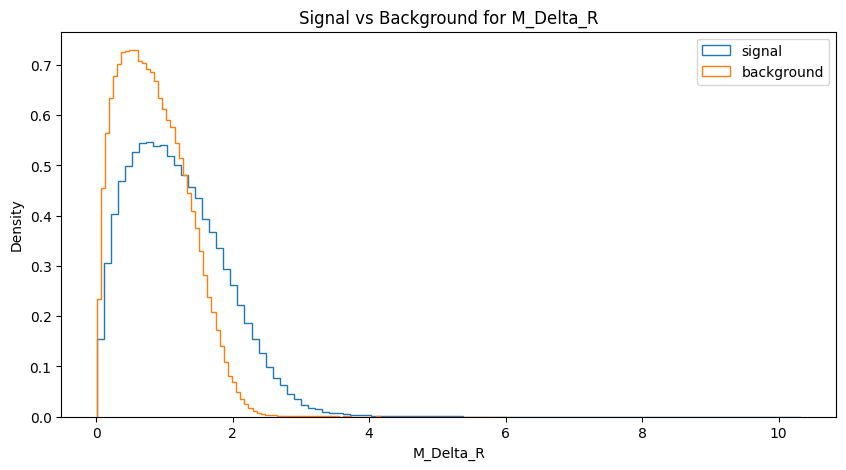

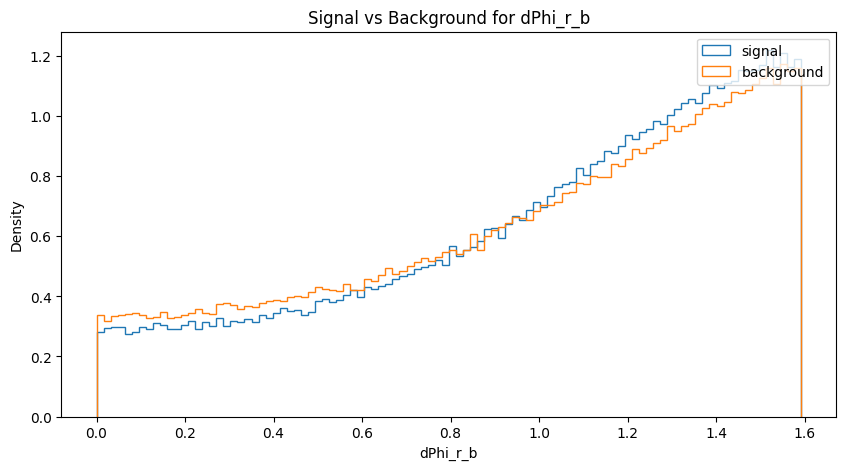

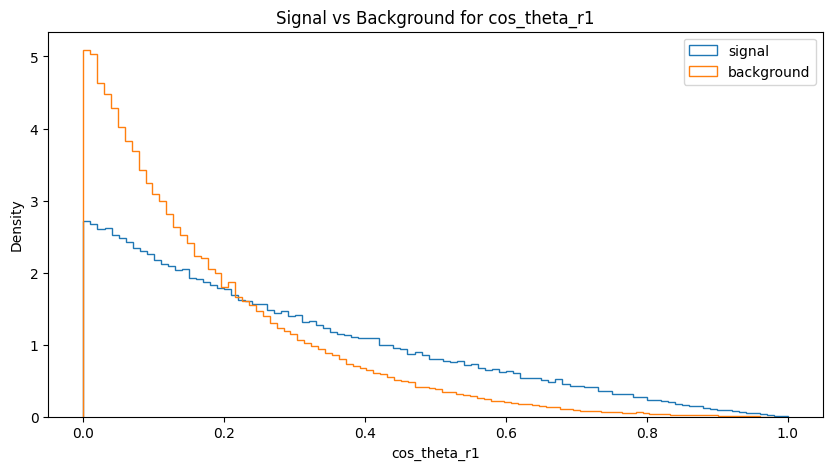

In [13]:
import numpy as np

# I compare signal and background for each observable.
# If the two histograms have noticeably different shapes, that variable may help separate the classes.
for var in VarNames[1:]:
    plt.figure(figsize=(10, 5))
    plt.hist(df_sig[var], bins=100, histtype="step", label="signal", density=True)
    plt.hist(df_bkg[var], bins=100, histtype="step", label="background", density=True)
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.title(f"Signal vs Background for {var}")
    plt.legend(loc="upper right")
    plt.show()


## Exercise 3: Make nice figures

Now use `matplotlib` to reproduce as closely as you can figures 5 and 6 from the paper. This exercise is intended to get you to familiarize yourself with making nicely formatted `matplotlib` figures with multiple plots. Note that the plots in the paper are actually wrong!

In [14]:
# I read the smaller dataset again with column names so the plots are easier to understand.
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype="float64", names=VarNames)


In [15]:
# I split the dataframe again after re-reading the file.
# This makes sure df_sig and df_bkg match the current dataframe.
df_sig = df[df["signal"] == 1]
df_bkg = df[df["signal"] == 0]


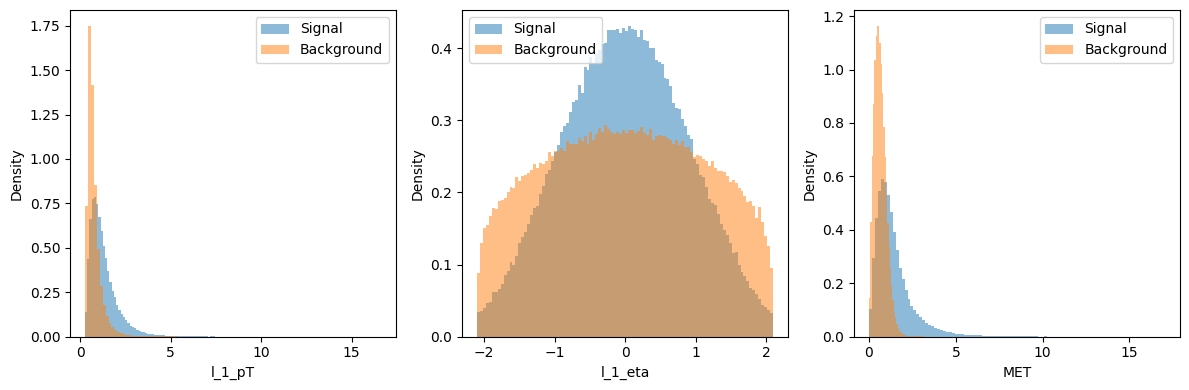

In [16]:
# I plot a few representative variables in one row.
# The goal is to compare the signal and background shapes clearly.
plt.figure(figsize=(12, 4))

variables = ["l_1_pT", "l_1_eta", "MET"]

for i, var in enumerate(variables):
    plt.subplot(1, 3, i + 1)
    plt.hist(df_sig[var], bins=100, density=True, alpha=0.5, label="Signal")
    plt.hist(df_bkg[var], bins=100, density=True, alpha=0.5, label="Background")
    plt.xlabel(var)
    plt.ylabel("Density")
    plt.legend()

plt.tight_layout()
plt.show()


I am using histograms to compare signal and background distributions. If the two distributions are separated or shaped differently, then that variable may be useful for classification.

## Exercise 4: Correlation

### Exercise 4.1

#### Part a
Write a function that creates pair plots and use it to compare variables in the SUSY sample, separately for low and high-level features. Refer to Lecture 13 for details. Do not use `seaborn`.

#### Part b
Making these plots can be slow because creating each plot initiates a full loop over the data. Make at least one modification to your function in part a to speed it up. Can you propose a different method of creating histograms that would speed up making such pair plots?

#### Part c
Which observables appear to be best for separating signal from background?

In [17]:
# I read the smaller file with named columns so I can use the variable names directly.
filename = "SUSY-small.csv"
df = pd.read_csv(filename, dtype="float64", names=VarNames)

# I split the data again because the pair plot compares signal and background separately.
df_sig = df[df["signal"] == 1]
df_bkg = df[df["signal"] == 0]


In [18]:
def make_pair_plot(df_sig, df_bkg, var_list, nmax=2000):
    """Make a simple pair plot without seaborn."""
    
    # I only keep the first nmax rows from each class because pair plots can be slow.
    # This is the speed-up for part b: I plot a smaller sample instead of looping over all rows.
    sig_small = df_sig[var_list].iloc[:nmax]
    bkg_small = df_bkg[var_list].iloc[:nmax]

    n = len(var_list)
    plt.figure(figsize=(4 * n, 4 * n))

    for i, yvar in enumerate(var_list):
        for j, xvar in enumerate(var_list):
            plt.subplot(n, n, i * n + j + 1)

            if i == j:
                # On the diagonal, I compare one variable at a time using histograms.
                plt.hist(sig_small[xvar], bins=40, density=True, histtype="step", label="signal")
                plt.hist(bkg_small[xvar], bins=40, density=True, histtype="step", label="background")
            else:
                # Off the diagonal, I compare two variables at a time using scatter plots.
                plt.scatter(sig_small[xvar], sig_small[yvar], s=2, alpha=0.3, label="signal")
                plt.scatter(bkg_small[xvar], bkg_small[yvar], s=2, alpha=0.3, label="background")

            if i == n - 1:
                plt.xlabel(xvar)
            if j == 0:
                plt.ylabel(yvar)
            if i == 0 and j == 0:
                plt.legend(loc="best")

    plt.tight_layout()
    plt.show()


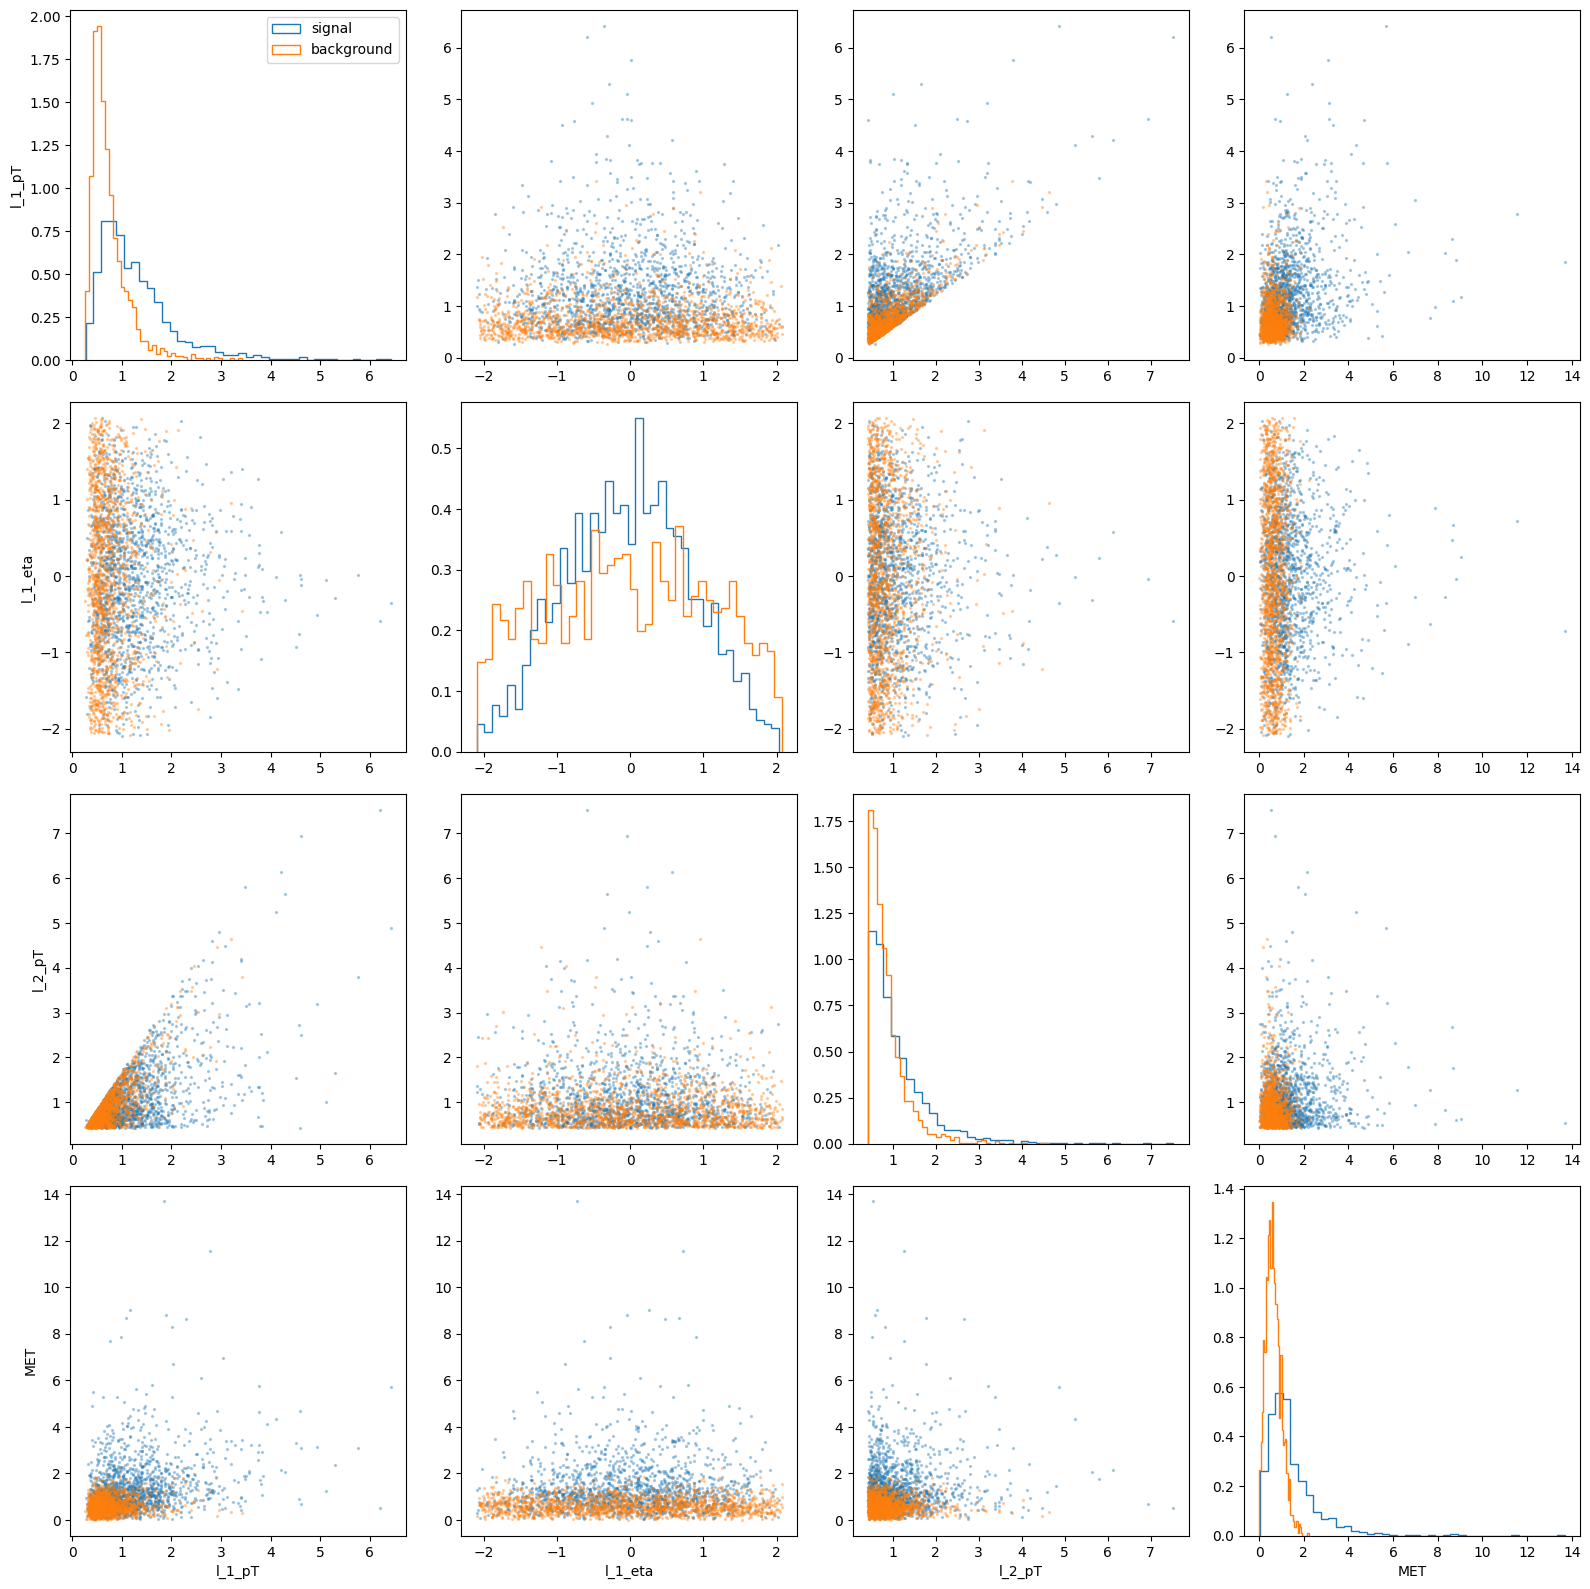

In [19]:
# raw variables
raw_vars = ["l_1_pT", "l_1_eta", "l_2_pT", "MET"]
make_pair_plot(df_sig, df_bkg, raw_vars, nmax=1500)

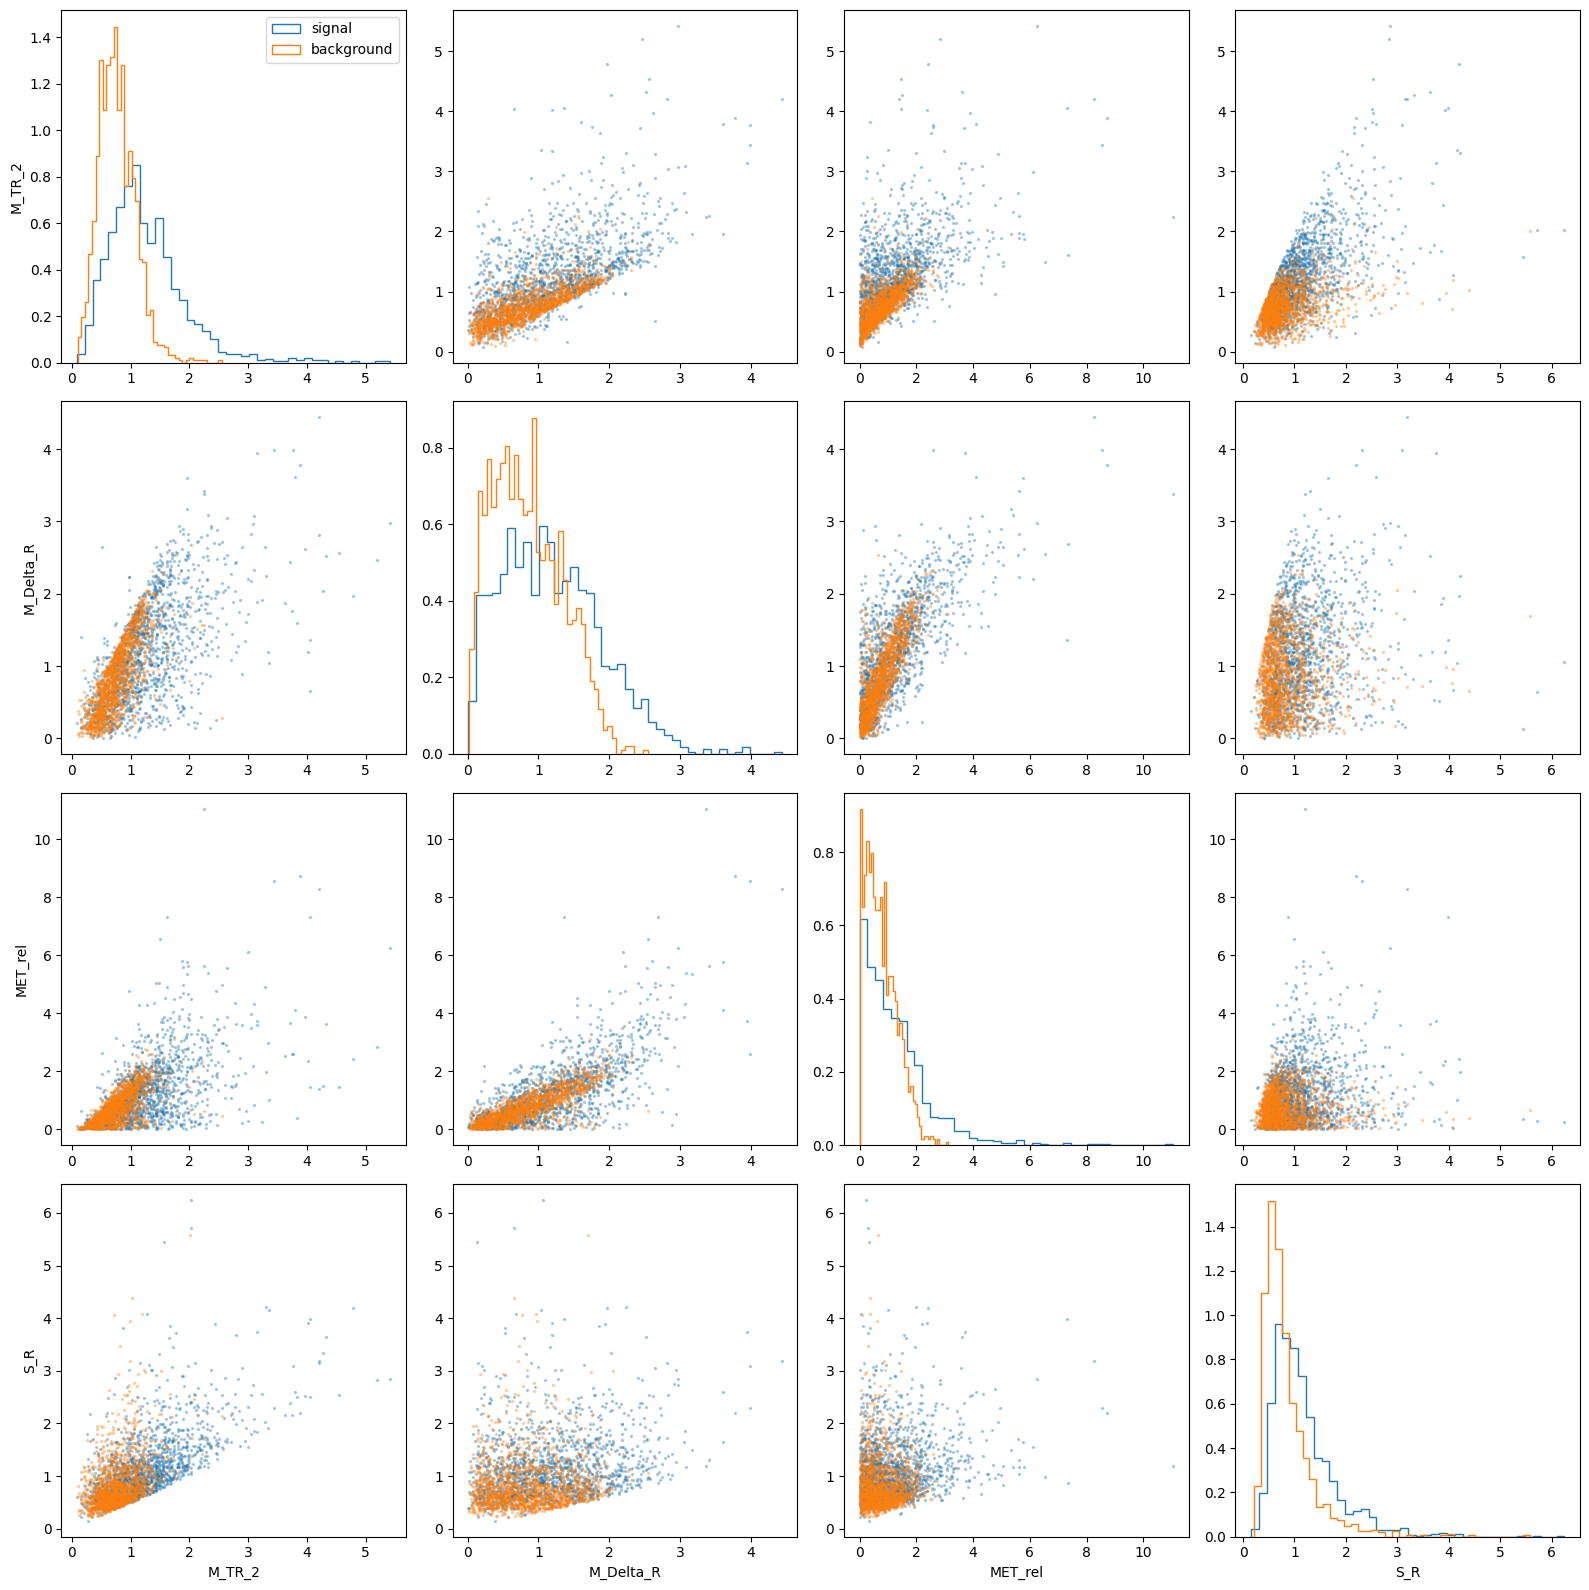

In [20]:
# high level variables
high_vars = ["M_TR_2", "M_Delta_R", "MET_rel", "S_R"]
make_pair_plot(df_sig, df_bkg, high_vars, nmax=1500)

I used only part of the data with nmax to make the pair plots faster. A faster method could be using 2D histograms or hexbin plots instead of scatter plots, because those methods summarize dense regions instead of drawing every point. From the plots, the high-level variables seem to separate signal and background better than the raw variables. In my plots, M_TR_2, M_Delta_R, and MET_re` look especially useful.

### Exercise 4.2

#### Part a
Install [tabulate](https://github.com/astanin/python-tabulate). 

#### Part b
Use numpy to compute the [covariance matrix](https://numpy.org/doc/stable/reference/generated/numpy.cov.html) and [correlation matrix](https://numpy.org/doc/stable/reference/generated/numpy.corrcoef.html) between all observabes, and separately between low and high-level features.

#### Part c
Use tabulate to create a well formatted table of the covariance and correlation matrices, with nice headings and appropriate significant figures. Embed the table into this notebook.

#### Part d
Write a function that takes a dataset and appropriate arguments and performs steps b and c.  

In [21]:
import sys
import subprocess

# I try to import tabulate first. If it is missing, I install it using the same Python running this notebook.
try:
    import tabulate
except ImportError:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "tabulate"])
    import tabulate

from IPython.display import HTML, display


Hint: Example code for embedding a `tabulate` table into a notebook:

In [22]:
from IPython.display import HTML, display
import tabulate
table = [["A",1,2],
        ["C",3,4],
        ["D",5,6]]
display(HTML(tabulate.tabulate(table, tablefmt='html', headers=["X","Y","Z"])))

X,Y,Z
A,1,2
C,3,4
D,5,6


In [23]:
def show_cov_corr(df_in, var_list, title="Table"):
    
    # I convert the selected dataframe columns into a NumPy array.
    # I transpose it because np.cov and np.corrcoef expect variables as rows.
    x = np.array(df_in[var_list]).T
    
    # I compute covariance to measure how variables change together.
    cov_matrix = np.cov(x)
    
    # I compute correlation because it is scaled from -1 to 1 and easier to compare.
    corr_matrix = np.corrcoef(x)
    
    # I display the covariance matrix as an HTML table with row and column names.
    print(title, "- Covariance Matrix")
    display(HTML(tabulate.tabulate(cov_matrix,
                                   headers=var_list,
                                   showindex=var_list,
                                   tablefmt="html",
                                   floatfmt=".3f")))
    
    # I display the correlation matrix the same way so the two tables are easy to compare.
    print(title, "- Correlation Matrix")
    display(HTML(tabulate.tabulate(corr_matrix,
                                   headers=var_list,
                                   showindex=var_list,
                                   tablefmt="html",
                                   floatfmt=".3f")))
    
    return cov_matrix, corr_matrix


In [24]:
show_cov_corr(df, RawNames, "Raw Variables")

Raw Variables - Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,0.467,-0.000,0.000,0.305,-0.000,0.001,0.228,-0.001
l_1_eta,-0.000,1.004,-0.001,-0.000,0.408,-0.001,-0.002,-0.001
l_1_phi,0.000,-0.001,1.004,0.001,0.000,-0.267,0.001,-0.185
l_2_pT,0.305,-0.000,0.001,0.425,-0.001,0.000,0.079,-0.002
l_2_eta,-0.000,0.408,0.000,-0.001,1.006,0.000,0.000,-0.000
l_2_phi,0.001,-0.001,-0.267,0.000,0.000,1.004,-0.000,-0.035
MET,0.228,-0.002,0.001,0.079,0.000,-0.000,0.762,-0.003
MET_phi,-0.001,-0.001,-0.185,-0.002,-0.000,-0.035,-0.003,1.003


Raw Variables - Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi
l_1_pT,1.000,-0.001,0.000,0.684,-0.001,0.001,0.383,-0.001
l_1_eta,-0.001,1.000,-0.001,-0.000,0.406,-0.001,-0.002,-0.001
l_1_phi,0.000,-0.001,1.000,0.002,0.000,-0.266,0.001,-0.184
l_2_pT,0.684,-0.000,0.002,1.000,-0.001,0.000,0.140,-0.002
l_2_eta,-0.001,0.406,0.000,-0.001,1.000,0.000,0.000,-0.000
l_2_phi,0.001,-0.001,-0.266,0.000,0.000,1.000,-0.000,-0.035
MET,0.383,-0.002,0.001,0.140,0.000,-0.000,1.000,-0.003
MET_phi,-0.001,-0.001,-0.184,-0.002,-0.000,-0.035,-0.003,1.000


(array([[ 4.67481925e-01, -3.96674207e-04,  7.66214265e-05,
          3.05037988e-01, -3.48826988e-04,  7.37336647e-04,
          2.28434336e-01, -9.36714374e-04],
        [-3.96674207e-04,  1.00430144e+00, -8.57630732e-04,
         -1.62905654e-04,  4.08312894e-01, -1.04201049e-03,
         -2.14697798e-03, -5.88968323e-04],
        [ 7.66214265e-05, -8.57630732e-04,  1.00397336e+00,
          1.31296001e-03,  2.50714928e-04, -2.66810178e-01,
          7.66365893e-04, -1.84803977e-01],
        [ 3.05037988e-01, -1.62905654e-04,  1.31296001e-03,
          4.25490163e-01, -5.75571383e-04,  1.55883996e-04,
          7.94518800e-02, -1.56177040e-03],
        [-3.48826988e-04,  4.08312894e-01,  2.50714928e-04,
         -5.75571383e-04,  1.00626446e+00,  4.41588261e-04,
          3.81652056e-04, -3.22449476e-04],
        [ 7.37336647e-04, -1.04201049e-03, -2.66810178e-01,
          1.55883996e-04,  4.41588261e-04,  1.00379832e+00,
         -3.03975643e-04, -3.54343031e-02],
        [ 2.2843

In [25]:
show_cov_corr(df, FeatureNames, "High-Level Features")

High-Level Features - Covariance Matrix


,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,0.790,-0.120,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.120,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054
M_R,0.044,0.017,0.392,0.210,-0.113,-0.037,0.380,0.074,-0.029,-0.014
M_TR_2,0.302,-0.185,0.210,0.338,0.104,0.189,0.228,0.242,0.058,0.052
R,0.249,-0.181,-0.113,0.104,0.222,0.232,-0.083,0.165,0.087,0.058
MT2,0.409,-0.461,-0.037,0.189,0.232,0.738,-0.011,0.433,0.021,0.045
S_R,0.082,-0.041,0.380,0.228,-0.083,-0.011,0.382,0.096,-0.003,-0.010
M_Delta_R,0.415,-0.233,0.074,0.242,0.165,0.433,0.096,0.389,0.042,0.039
dPhi_r_b,0.146,-0.025,-0.029,0.058,0.087,0.021,-0.003,0.042,0.190,0.009
cos_theta_r1,0.055,-0.054,-0.014,0.052,0.058,0.045,-0.010,0.039,0.009,0.039


High-Level Features - Correlation Matrix


,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
MET_rel,1.000,-0.134,0.078,0.584,0.595,0.535,0.150,0.748,0.378,0.316
axial_MET,-0.134,1.000,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272
M_R,0.078,0.027,1.000,0.577,-0.383,-0.068,0.981,0.189,-0.106,-0.116
M_TR_2,0.584,-0.317,0.577,1.000,0.380,0.379,0.635,0.668,0.229,0.451
R,0.595,-0.383,-0.383,0.380,1.000,0.574,-0.287,0.564,0.424,0.627
MT2,0.535,-0.535,-0.068,0.379,0.574,1.000,-0.021,0.809,0.056,0.264
S_R,0.150,-0.067,0.981,0.635,-0.287,-0.021,1.000,0.249,-0.013,-0.085
M_Delta_R,0.748,-0.373,0.189,0.668,0.564,0.809,0.249,1.000,0.155,0.319
dPhi_r_b,0.378,-0.057,-0.106,0.229,0.424,0.056,-0.013,0.155,1.000,0.106
cos_theta_r1,0.316,-0.272,-0.116,0.451,0.627,0.264,-0.085,0.319,0.106,1.000


(array([[ 0.79048911, -0.1198512 ,  0.04368455,  0.30199264,  0.24882357,
          0.40877889,  0.08231538,  0.41474304,  0.1464394 ,  0.05531787],
        [-0.1198512 ,  1.00537396,  0.01713455, -0.18501679, -0.18090014,
         -0.46099861, -0.04138282, -0.23307398, -0.02511279, -0.05373485],
        [ 0.04368455,  0.01713455,  0.39216708,  0.20987467, -0.11290414,
         -0.03654441,  0.37976344,  0.07393003, -0.02896168, -0.01434118],
        [ 0.30199264, -0.18501679,  0.20987467,  0.33782719,  0.10401425,
          0.18916951,  0.2281247 ,  0.24186516,  0.05813297,  0.05166586],
        [ 0.24882357, -0.18090014, -0.11290414,  0.10401425,  0.22157807,
          0.23210005, -0.08335872,  0.16548304,  0.08709136,  0.05816081],
        [ 0.40877889, -0.46099861, -0.03654441,  0.18916951,  0.23210005,
          0.73766054, -0.01103752,  0.43289693,  0.02089723,  0.04462891],
        [ 0.08231538, -0.04138282,  0.37976344,  0.2281247 , -0.08335872,
         -0.01103752,  0.3820146

In [26]:
show_cov_corr(df, VarNames[1:], "All Variables")

All Variables - Covariance Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,0.467,-0.000,0.000,0.305,-0.000,0.001,0.228,-0.001,0.098,-0.010,0.364,0.287,-0.060,-0.012,0.343,0.098,-0.047,0.022
l_1_eta,-0.000,1.004,-0.001,-0.000,0.408,-0.001,-0.002,-0.001,-0.001,-0.001,-0.001,-0.001,0.000,0.000,-0.001,-0.001,-0.001,0.000
l_1_phi,0.000,-0.001,1.004,0.001,0.000,-0.267,0.001,-0.185,0.001,-0.002,0.001,0.001,0.000,0.001,0.001,0.001,0.001,0.000
l_2_pT,0.305,-0.000,0.001,0.425,-0.001,0.000,0.079,-0.002,-0.001,0.051,0.325,0.163,-0.099,-0.069,0.322,0.006,-0.004,-0.028
l_2_eta,-0.000,0.408,0.000,-0.001,1.006,0.000,0.000,-0.000,0.001,-0.001,-0.001,0.000,0.000,0.001,-0.001,0.001,-0.000,0.000
l_2_phi,0.001,-0.001,-0.267,0.000,0.000,1.004,-0.000,-0.035,0.001,-0.002,0.001,0.001,0.001,0.002,0.001,0.001,-0.000,0.000
MET,0.228,-0.002,0.001,0.079,0.000,-0.000,0.762,-0.003,0.546,0.154,0.145,0.365,0.188,0.155,0.166,0.315,0.146,0.073
MET_phi,-0.001,-0.001,-0.185,-0.002,-0.000,-0.035,-0.003,1.003,-0.005,-0.000,-0.001,-0.001,-0.000,0.000,-0.002,-0.001,-0.002,0.000
MET_rel,0.098,-0.001,0.001,-0.001,0.001,0.001,0.546,-0.005,0.790,-0.120,0.044,0.302,0.249,0.409,0.082,0.415,0.146,0.055
axial_MET,-0.010,-0.001,-0.002,0.051,-0.001,-0.002,0.154,-0.000,-0.120,1.005,0.017,-0.185,-0.181,-0.461,-0.041,-0.233,-0.025,-0.054


All Variables - Correlation Matrix


,l_1_pT,l_1_eta,l_1_phi,l_2_pT,l_2_eta,l_2_phi,MET,MET_phi,MET_rel,axial_MET,M_R,M_TR_2,R,MT2,S_R,M_Delta_R,dPhi_r_b,cos_theta_r1
l_1_pT,1.000,-0.001,0.000,0.684,-0.001,0.001,0.383,-0.001,0.160,-0.014,0.851,0.723,-0.186,-0.021,0.811,0.229,-0.157,0.165
l_1_eta,-0.001,1.000,-0.001,-0.000,0.406,-0.001,-0.002,-0.001,-0.002,-0.001,-0.001,-0.001,0.001,0.000,-0.001,-0.002,-0.002,0.002
l_1_phi,0.000,-0.001,1.000,0.002,0.000,-0.266,0.001,-0.184,0.001,-0.002,0.002,0.001,0.000,0.001,0.002,0.001,0.002,0.001
l_2_pT,0.684,-0.000,0.002,1.000,-0.001,0.000,0.140,-0.002,-0.001,0.078,0.797,0.430,-0.324,-0.123,0.799,0.014,-0.013,-0.217
l_2_eta,-0.001,0.406,0.000,-0.001,1.000,0.000,0.000,-0.000,0.001,-0.001,-0.001,0.000,0.001,0.002,-0.001,0.001,-0.001,0.001
l_2_phi,0.001,-0.001,-0.266,0.000,0.000,1.000,-0.000,-0.035,0.002,-0.002,0.001,0.001,0.001,0.003,0.001,0.002,-0.001,0.000
MET,0.383,-0.002,0.001,0.140,0.000,-0.000,1.000,-0.003,0.704,0.176,0.264,0.720,0.457,0.206,0.307,0.579,0.383,0.425
MET_phi,-0.001,-0.001,-0.184,-0.002,-0.000,-0.035,-0.003,1.000,-0.005,-0.000,-0.002,-0.002,-0.000,0.000,-0.003,-0.001,-0.004,0.001
MET_rel,0.160,-0.002,0.001,-0.001,0.001,0.002,0.704,-0.005,1.000,-0.134,0.078,0.584,0.595,0.535,0.150,0.748,0.378,0.316
axial_MET,-0.014,-0.001,-0.002,0.078,-0.001,-0.002,0.176,-0.000,-0.134,1.000,0.027,-0.317,-0.383,-0.535,-0.067,-0.373,-0.057,-0.272


(array([[ 4.67481925e-01, -3.96674207e-04,  7.66214265e-05,
          3.05037988e-01, -3.48826988e-04,  7.37336647e-04,
          2.28434336e-01, -9.36714374e-04,  9.75240349e-02,
         -9.73253567e-03,  3.64432455e-01,  2.87223483e-01,
         -5.97024601e-02, -1.23988205e-02,  3.42587023e-01,
          9.77389248e-02, -4.69491360e-02,  2.21632465e-02],
        [-3.96674207e-04,  1.00430144e+00, -8.57630732e-04,
         -1.62905654e-04,  4.08312894e-01, -1.04201049e-03,
         -2.14697798e-03, -5.88968323e-04, -1.37057212e-03,
         -1.10889241e-03, -5.53826632e-04, -6.68920291e-04,
          3.01299870e-04,  4.27122683e-04, -6.04009571e-04,
         -9.87471350e-04, -7.40330277e-04,  3.21632240e-04],
        [ 7.66214265e-05, -8.57630732e-04,  1.00397336e+00,
          1.31296001e-03,  2.50714928e-04, -2.66810178e-01,
          7.66365893e-04, -1.84803977e-01,  7.06206018e-04,
         -1.87269105e-03,  1.06306621e-03,  8.68782730e-04,
          2.01595554e-04,  1.06029189e

I used the covariance and correlation matrices to compare relationships between variables. The covariance matrix shows how variables change together, but the correlation matrix is easier for me to interpret because every value is scaled between -1 and 1. I noticed that some variables are strongly correlated, especially among the high-level features. That suggests some high-level features contain overlapping information. The raw variables generally show weaker correlations compared to the high-level features.

## Exercise 5: Selection

### Exercise 5.1

Part a
By looking at the signal/background distributions for each observable (e.g. $x$) determine which selection criteria would be optimal: 

1. $x > x_c$
2. $x < x_c$
3. $|x - \mu| > x_c$
4. $|x - \mu| < x_c$

where $x_c$ is value to be determined below.

### Exercise 5.2

Plot the True Positive Rate (TPR) (aka signal efficiency $\epsilon_S(x_c)$) and False Positive Rate (FPR) (aka background efficiency $\epsilon_B(x_c)$) as function of $x_c$ for applying the strategy in part a to each observable. 

### Exercise 5.3
Assume 3 different scenarios corresponding to different numbers of signal and background events expected in data:

1. Expect $N_S=10$, $N_B=100$.
1. Expect $N_S=100$, $N_B=1000$.
1. Expect $N_S=1000$, $N_B=10000$.
1. Expect $N_S=10000$, $N_B=100000$.

Plot the significance ($\sigma_{S'}$) for each observable as function of $x_c$ for each scenario, where 

$\sigma_{S'}= \frac{N'_S}{\sqrt{N'_S+N'_B}}$

and $N'_{S,B} = \epsilon_{S,B}(x_c) * N_{S,B}$.

By comparing the signal and background histograms, I chose `x > x_c` as the main selection rule for the variables I tested. I chose this because many signal distributions are shifted toward larger values than the background distributions. Some observables could use a different rule, but the greater-than cut is a clear starting point for these plots.

In [27]:
def compute_rate(d, bins=100):
    """Compute the fraction of events that survive a cut x > x_c."""
    
    # I use counts instead of density because I want an actual fraction of events.
    hist, bin_edges = np.histogram(d, bins=bins)
    
    # I add the bin counts from right to left.
    # This gives the number of events with x greater than each cut value.
    surviving_counts = np.cumsum(hist[::-1])[::-1]
    
    # I divide by the total number of events so the result is an efficiency from 0 to 1.
    survival_rate = surviving_counts / len(d)
    
    return survival_rate, bin_edges


def compute_tpr_fpr(df_sig, df_bkg, obs_name, bins=100):
    """Compute TPR and FPR with the same cut values for signal and background."""
    
    # I build the bin edges from signal and background together.
    # This keeps both classes on the same x_c values and avoids dropping out-of-range events.
    all_values = np.concatenate([df_sig[obs_name].to_numpy(), df_bkg[obs_name].to_numpy()])
    bin_edges = np.histogram_bin_edges(all_values, bins=bins)
    
    # I use the same bin edges for signal and background so the rates are comparable.
    TPR, bin_edges = compute_rate(df_sig[obs_name], bins=bin_edges)
    FPR, bin_edges = compute_rate(df_bkg[obs_name], bins=bin_edges)
    cut_values = bin_edges[:-1]
    
    return TPR, FPR, cut_values


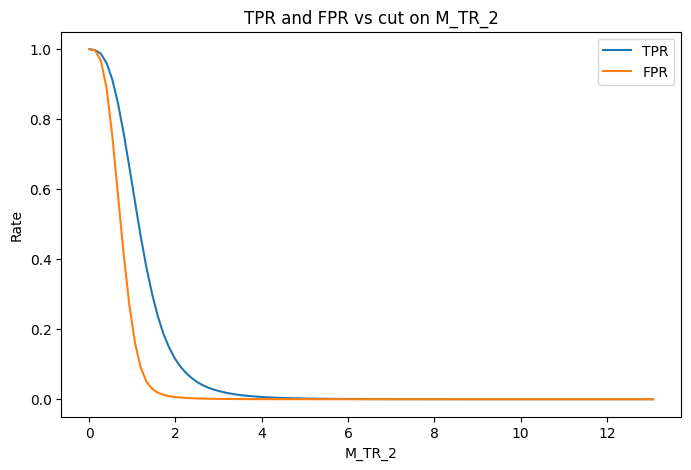

In [28]:
# I start with one observable to check that the TPR and FPR calculation works.
obs = "M_TR_2"

TPR, FPR, cut_values = compute_tpr_fpr(df_sig, df_bkg, obs, bins=100)

plt.figure(figsize=(8, 5))
plt.plot(cut_values, TPR, label="TPR")
plt.plot(cut_values, FPR, label="FPR")
plt.xlabel(obs)
plt.ylabel("Rate")
plt.title(f"TPR and FPR vs cut on {obs}")
plt.legend()
plt.show()


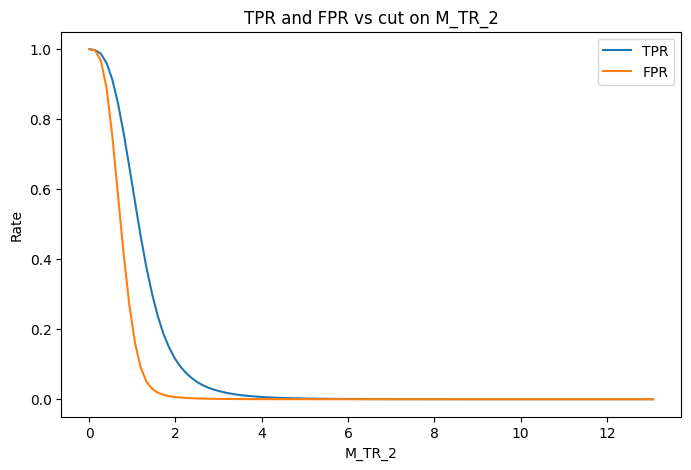

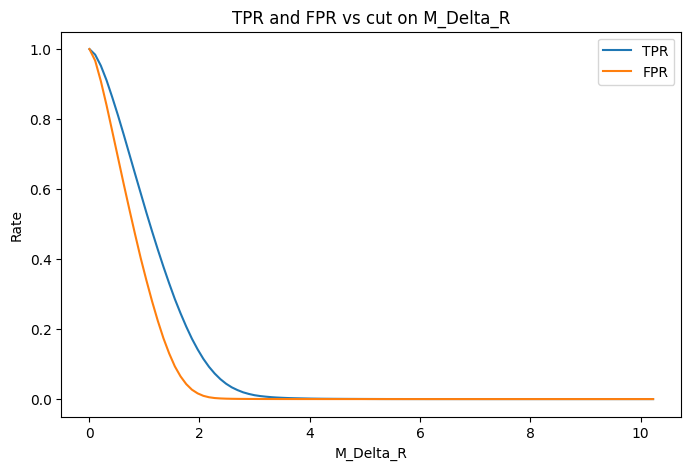

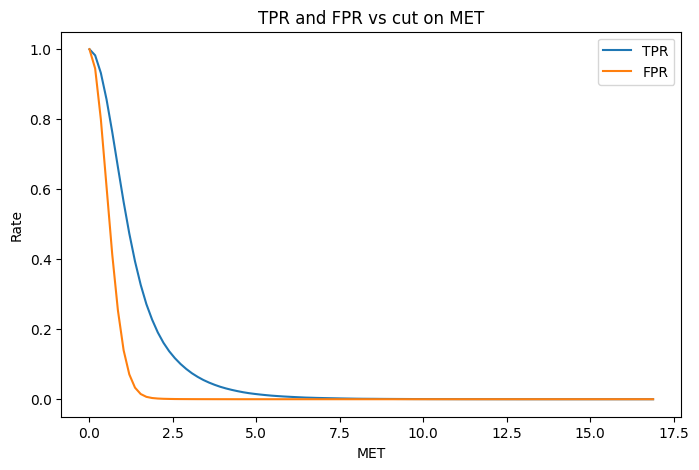

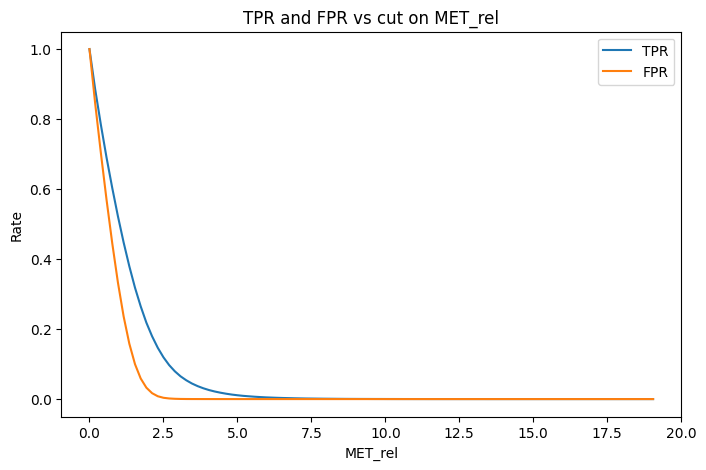

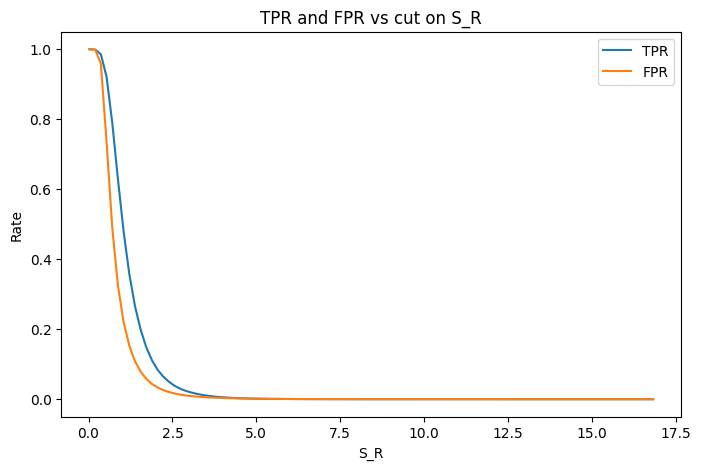

In [29]:
# I repeat the TPR/FPR plot for several observables that looked useful from the histograms.
for obs in ["M_TR_2", "M_Delta_R", "MET", "MET_rel", "S_R"]:
    TPR, FPR, cut_values = compute_tpr_fpr(df_sig, df_bkg, obs, bins=100)

    plt.figure(figsize=(8, 5))
    plt.plot(cut_values, TPR, label="TPR")
    plt.plot(cut_values, FPR, label="FPR")
    plt.xlabel(obs)
    plt.ylabel("Rate")
    plt.title(f"TPR and FPR vs cut on {obs}")
    plt.legend()
    plt.show()


In [30]:
def compare_significance(df_sig, df_bkg, obs_name, scenarios, bins=100, log=False):
    
    # I compute the signal and background efficiencies for the cut x > x_c.
    TPR, FPR, cut_values = compute_tpr_fpr(df_sig, df_bkg, obs_name, bins=bins)
    
    table = []
    
    for name, (n_sig_expected, n_bkg_expected) in scenarios.items():
        # I scale the efficiencies by the expected event counts.
        n_sig_prime = n_sig_expected * TPR
        n_bkg_prime = n_bkg_expected * FPR
        total_prime = n_sig_prime + n_bkg_prime
        
        # I compute significance safely so I do not divide by zero.
        sig = np.divide(n_sig_prime, np.sqrt(total_prime),
                        out=np.zeros_like(n_sig_prime),
                        where=total_prime > 0)
        
        # I plot significance as a function of the cut value.
        plt.step(cut_values, sig, where="post", label=name)
        
        # I find the cut that gives the largest significance for this scenario.
        max_i = int(np.argmax(sig))
        table.append((name,
                      n_sig_expected,
                      n_bkg_expected,
                      TPR[max_i],
                      FPR[max_i],
                      n_sig_prime[max_i],
                      n_bkg_prime[max_i],
                      sig[max_i],
                      cut_values[max_i]))
    
    if log:
        plt.yscale("log")
    
    plt.xlabel(obs_name)
    plt.ylabel("Significance")
    plt.title(f"Significance vs cut for {obs_name}")
    plt.legend(title="Scenario")
    plt.show()
    
    display(HTML(tabulate.tabulate(
        table,
        headers=["Scenario", "N_S", "N_B", "TPR", "FPR", "N_S'", "N_B'", "sig", "x_c"],
        tablefmt="html",
        floatfmt=".4f"
    )))
    
    return table


In [31]:
scenarios = {
    "1": (10, 100),
    "2": (100, 1000),
    "3": (1000, 10000),
    "4": (10000, 100000)
}

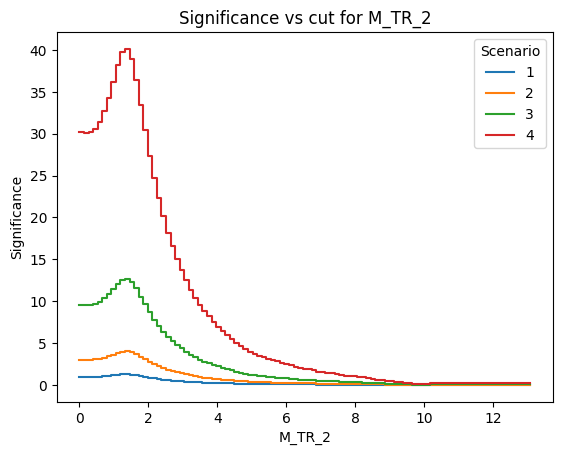

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.3773,0.0507,3.7731,5.0681,1.2690,1.3286
2,100,1000,0.3773,0.0507,37.7312,50.6805,4.0128,1.3286
3,1000,10000,0.3773,0.0507,377.3125,506.8050,12.6895,1.3286
4,10000,100000,0.3773,0.0507,3773.1248,5068.0505,40.1279,1.3286


[('1',
  10,
  100,
  np.float64(0.3773124822787847),
  np.float64(0.050680504515152075),
  np.float64(3.7731248227878473),
  np.float64(5.068050451515208),
  np.float64(1.2689548576154583),
  np.float64(1.328614060394466)),
 ('2',
  100,
  1000,
  np.float64(0.3773124822787847),
  np.float64(0.050680504515152075),
  np.float64(37.731248227878474),
  np.float64(50.68050451515207),
  np.float64(4.012787597999512),
  np.float64(1.328614060394466)),
 ('3',
  1000,
  10000,
  np.float64(0.3773124822787847),
  np.float64(0.050680504515152075),
  np.float64(377.3124822787847),
  np.float64(506.80504515152074),
  np.float64(12.689548576154584),
  np.float64(1.328614060394466)),
 ('4',
  10000,
  100000,
  np.float64(0.3773124822787847),
  np.float64(0.050680504515152075),
  np.float64(3773.1248227878473),
  np.float64(5068.050451515208),
  np.float64(40.12787597999511),
  np.float64(1.328614060394466))]

In [32]:
compare_significance(df_sig, df_bkg, "M_TR_2", scenarios)

M_TR_2


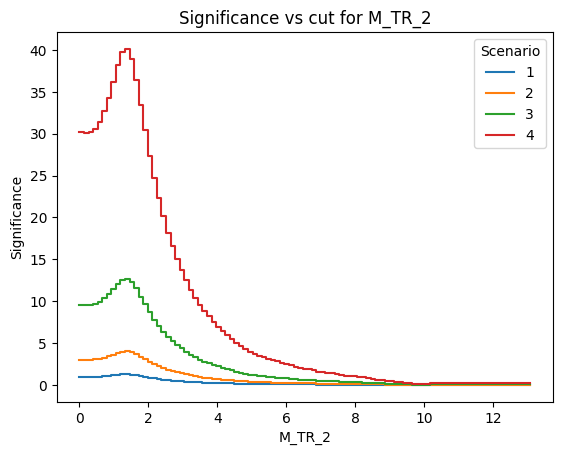

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.3773,0.0507,3.7731,5.0681,1.2690,1.3286
2,100,1000,0.3773,0.0507,37.7312,50.6805,4.0128,1.3286
3,1000,10000,0.3773,0.0507,377.3125,506.8050,12.6895,1.3286
4,10000,100000,0.3773,0.0507,3773.1248,5068.0505,40.1279,1.3286


M_Delta_R


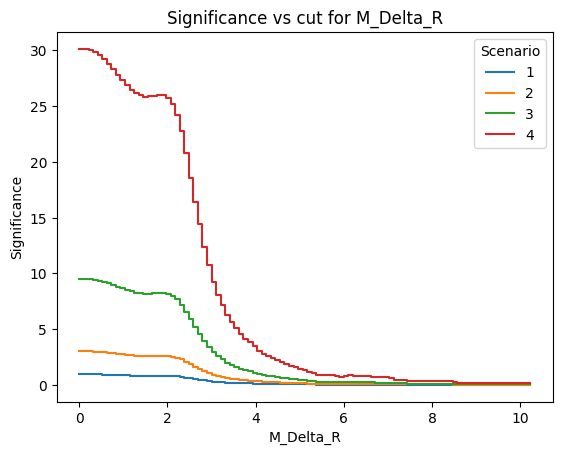

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,1.0000,1.0000,10.0000,100.0000,0.9535,0.0045
2,100,1000,1.0000,1.0000,100.0000,1000.0000,3.0151,0.0045
3,1000,10000,1.0000,1.0000,1000.0000,10000.0000,9.5346,0.0045
4,10000,100000,1.0000,1.0000,10000.0000,100000.0000,30.1511,0.0045


MET


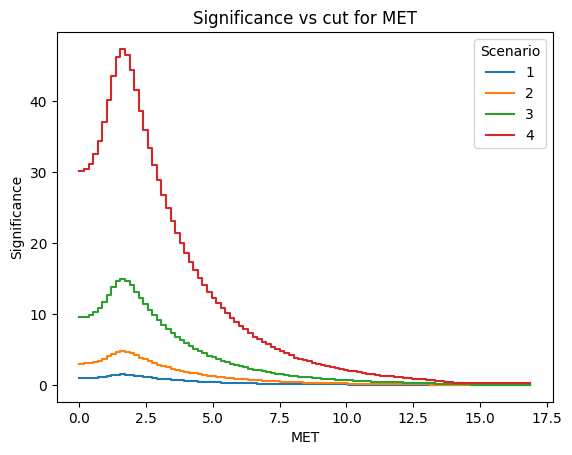

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.3269,0.0148,3.2690,1.4840,1.4995,1.5356
2,100,1000,0.3269,0.0148,32.6904,14.8400,4.7417,1.5356
3,1000,10000,0.3269,0.0148,326.9035,148.3998,14.9946,1.5356
4,10000,100000,0.3269,0.0148,3269.0353,1483.9984,47.4170,1.5356


MET_rel


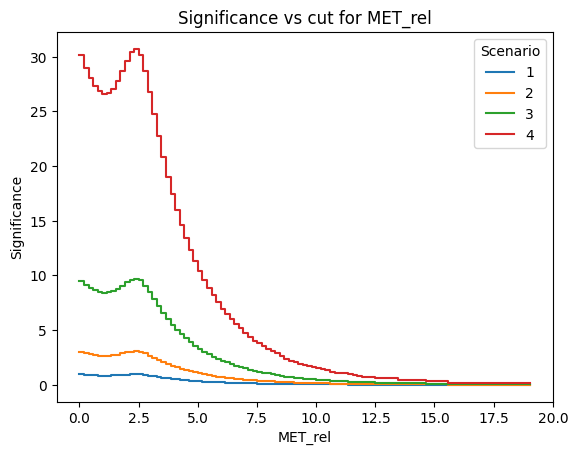

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.1466,0.0081,1.4656,0.8100,0.9716,2.3091
2,100,1000,0.1466,0.0081,14.6559,8.0996,3.0723,2.3091
3,1000,10000,0.1466,0.0081,146.5594,80.9957,9.7156,2.3091
4,10000,100000,0.1466,0.0081,1465.5936,809.9573,30.7235,2.3091


S_R


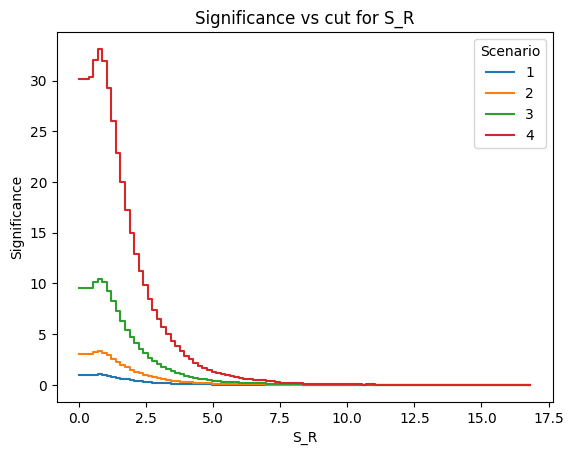

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.7906,0.4909,7.9059,49.0890,1.0472,0.7058
2,100,1000,0.7906,0.4909,79.0586,490.8903,3.3116,0.7058
3,1000,10000,0.7906,0.4909,790.5865,4908.9029,10.4720,0.7058
4,10000,100000,0.7906,0.4909,7905.8649,49089.0288,33.1155,0.7058


In [33]:
for obs in ["M_TR_2", "M_Delta_R", "MET", "MET_rel", "S_R"]:
    print(obs)
    compare_significance(df_sig, df_bkg, obs, scenarios)

The TPR and FPR curves show how signal efficiency and background efficiency change as the cut value increases. For cuts of the form `x > x_c`, both rates decrease as the threshold becomes tighter. A useful observable is one where the background efficiency drops faster than the signal efficiency, because that keeps more signal while removing more background.

The significance curves show that the best cut value depends on the observable and the expected signal and background yields. In general, the best variables keep a relatively high TPR while strongly reducing the FPR.

## Exercise 6: Cut Flow


### Exercise 6.1

For each above scenario, choose a subset (minumum 3) of observables to use for selections, and values of $x_c$ based on your significance plots (part 3c). 

### Exercise 6.2
Create a "cut-flow" table for each scenario where you successively make the selections on each observable and tabulate $\epsilon_S$, $\epsilon_B$, $N'_S$, $N'_B$, and $\sigma_{S'}$.

### Exercise 6.3
In 3c above you computed the significance for each observable assuming to make no other selections on any other observable. If the variables are correlated, then this assumption can lead to non-optimial results when selecting on multiple variables. By looking at the correlation matrices and your answers to 4b, identify where this effect could be most detrimental to the significance. Attempt to correct the issue by applying the selection in one observable and then optimizing (part 3c) for a second observable. What happens if you change the order of your selection (make selection on second and optimize on first)?




In [34]:
candidate_cut_vars = ["M_TR_2", "M_Delta_R", "MET_rel", "S_R", "MET"]

def find_best_cut(df_sig, df_bkg, obs_name, n_sig_expected, n_bkg_expected, bins=100):
    """Find the cut x_c that gives the best significance for one observable."""
    
    # I compute efficiencies for this observable first.
    TPR, FPR, cut_values = compute_tpr_fpr(df_sig, df_bkg, obs_name, bins=bins)
    
    # I convert efficiencies into expected surviving event counts.
    n_sig_prime = n_sig_expected * TPR
    n_bkg_prime = n_bkg_expected * FPR
    total_prime = n_sig_prime + n_bkg_prime
    
    # I compute significance and pick the cut with the largest value.
    sig = np.divide(n_sig_prime, np.sqrt(total_prime),
                    out=np.zeros_like(n_sig_prime),
                    where=total_prime > 0)
    best_i = int(np.argmax(sig))
    
    return {
        "Observable": obs_name,
        "x_c": cut_values[best_i],
        "eps_S": TPR[best_i],
        "eps_B": FPR[best_i],
        "N_S'": n_sig_prime[best_i],
        "N_B'": n_bkg_prime[best_i],
        "sig": sig[best_i]
    }


def choose_cuts(df_sig, df_bkg, candidate_vars, n_sig_expected, n_bkg_expected, n_keep=3, bins=100):
    """Choose the best n_keep observables by individual significance scans."""
    
    # I scan the candidate observables and keep the best cut for each one.
    rows = [find_best_cut(df_sig, df_bkg, obs, n_sig_expected, n_bkg_expected, bins=bins)
            for obs in candidate_vars]
    
    # I sort by significance so the strongest variables appear first.
    rows = sorted(rows, key=lambda row: row["sig"], reverse=True)
    
    display(HTML(tabulate.tabulate(
        [[row["Observable"], row["x_c"], row["eps_S"], row["eps_B"], row["N_S'"], row["N_B'"], row["sig"]]
         for row in rows],
        headers=["Observable", "x_c", "eps_S", "eps_B", "N_S'", "N_B'", "sig"],
        tablefmt="html",
        floatfmt=".4f"
    )))
    
    # I return only the observable name and cut value for the cut-flow table.
    return [(row["Observable"], row["x_c"]) for row in rows[:n_keep]]


def cut_flow(df_sig, df_bkg, cuts, n_sig_expected, n_bkg_expected, title="Cut flow"):
    """Apply cuts one at a time and report efficiencies and significance after each cut."""

    # I start with the full signal and background samples.
    df_sig_cut = df_sig.copy()
    df_bkg_cut = df_bkg.copy()
    rows = []
    
    for obs, xc in cuts:
        # I apply the selected cut x > x_c.
        df_sig_cut = df_sig_cut[df_sig_cut[obs] > xc]
        df_bkg_cut = df_bkg_cut[df_bkg_cut[obs] > xc]
        
        # I compute cumulative efficiencies relative to the original samples.
        eps_s = len(df_sig_cut) / len(df_sig)
        eps_b = len(df_bkg_cut) / len(df_bkg)
        
        # I convert efficiencies into expected remaining event counts.
        ns_p = eps_s * n_sig_expected
        nb_p = eps_b * n_bkg_expected
        
        # I compute the significance after this cut.
        sig = ns_p / np.sqrt(ns_p + nb_p) if (ns_p + nb_p) > 0 else 0
        rows.append([obs, xc, eps_s, eps_b, ns_p, nb_p, sig])
    
    print(title)
    display(HTML(tabulate.tabulate(
        rows,
        headers=["Observable", "x_c", "eps_S", "eps_B", "N_S'", "N_B'", "sig"],
        tablefmt="html",
        floatfmt=".4f"
    )))
    
    return rows


In [35]:
# I choose and apply cuts for each scenario.
# The scenarios have the same signal-to-background ratio, so the best cuts may be similar,
# but I still calculate them separately to show the full logic.
cuts_by_scenario = {}

for name, (n_s, n_b) in scenarios.items():
    print(f"Scenario {name}: choosing cuts")
    cuts_by_scenario[name] = choose_cuts(df_sig, df_bkg, candidate_cut_vars, n_s, n_b, n_keep=3)
    cut_flow(df_sig, df_bkg, cuts_by_scenario[name], n_s, n_b, title=f"Scenario {name} cut flow")


Scenario 1: choosing cuts


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
MET,1.5356,0.3269,0.0148,3.2690,1.4840,1.4995
M_TR_2,1.3286,0.3773,0.0507,3.7731,5.0681,1.2690
S_R,0.7058,0.7906,0.4909,7.9059,49.0890,1.0472
MET_rel,2.3091,0.1466,0.0081,1.4656,0.8100,0.9716
M_Delta_R,0.0045,1.0000,1.0000,10.0000,100.0000,0.9535


Scenario 1 cut flow


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
MET,1.5356,0.3269,0.0148,3.2690,1.4840,1.4995
M_TR_2,1.3286,0.2335,0.0107,2.3348,1.0659,1.2661
S_R,0.7058,0.2330,0.0105,2.3298,1.0474,1.2678


Scenario 2: choosing cuts


...

Observable,x_c,eps_S,eps_B,N_S',N_B',sig
MET,1.5356,0.3269,0.0148,326.9035,148.3998,14.9946
M_TR_2,1.3286,0.2335,0.0107,233.4795,106.5908,12.6609
S_R,0.7058,0.2330,0.0105,232.9822,104.7441,12.6777


Scenario 4: choosing cuts


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
MET,1.5356,0.3269,0.0148,3269.0353,1483.9984,47.4170
M_TR_2,1.3286,0.3773,0.0507,3773.1248,5068.0505,40.1279
S_R,0.7058,0.7906,0.4909,7905.8649,49089.0288,33.1155
MET_rel,2.3091,0.1466,0.0081,1465.5936,809.9573,30.7235
M_Delta_R,0.0045,1.0000,1.0000,10000.0000,100000.0000,30.1511


Scenario 4 cut flow


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
MET,1.5356,0.3269,0.0148,3269.0353,1483.9984,47.4170
M_TR_2,1.3286,0.2335,0.0107,2334.7947,1065.9083,40.0373
S_R,0.7058,0.2330,0.0105,2329.8218,1047.4414,40.0904


In [36]:
def compare_two_cut_orders(df_sig, df_bkg, obs_a, obs_b, n_sig_expected, n_bkg_expected, bins=100):
    """Compare what happens when I optimize two correlated cuts in different orders."""
    rows = []
    
    for first_obs, second_obs in [(obs_a, obs_b), (obs_b, obs_a)]:
        # I optimize the first observable on the original data.
        first = find_best_cut(df_sig, df_bkg, first_obs, n_sig_expected, n_bkg_expected, bins=bins)
        
        # I apply the first cut before optimizing the second observable.
        sig_after_first = df_sig[df_sig[first_obs] > first["x_c"]]
        bkg_after_first = df_bkg[df_bkg[first_obs] > first["x_c"]]
        
        # I optimize the second observable on the already-cut data.
        second = find_best_cut(sig_after_first, bkg_after_first, second_obs,
                               n_sig_expected, n_bkg_expected, bins=bins)
        
        # I apply both cuts in that order and record the final cut-flow row.
        final_rows = cut_flow(df_sig, df_bkg,
                              [(first_obs, first["x_c"]), (second_obs, second["x_c"])],
                              n_sig_expected, n_bkg_expected,
                              title=f"Order: {first_obs} then {second_obs}")
        final_sig = final_rows[-1][-1]
        rows.append([f"{first_obs} then {second_obs}", first["x_c"], second["x_c"], final_sig])
    
    print("Order comparison")
    display(HTML(tabulate.tabulate(
        rows,
        headers=["Order", "First x_c", "Second x_c", "Final sig"],
        tablefmt="html",
        floatfmt=".4f"
    )))
    
    return rows

# I use M_TR_2 and M_Delta_R because the correlation table showed that high-level variables can be correlated.
compare_two_cut_orders(df_sig, df_bkg, "M_TR_2", "M_Delta_R", 100, 1000)


Order: M_TR_2 then M_Delta_R


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
M_TR_2,1.3286,0.3773,0.0507,37.7312,50.6805,4.0128
M_Delta_R,0.0069,0.3773,0.0507,37.7308,50.6805,4.0128


Order: M_Delta_R then M_TR_2


Observable,x_c,eps_S,eps_B,N_S',N_B',sig
M_Delta_R,0.0045,1.0000,1.0000,99.9996,1000.0000,3.0151
M_TR_2,1.3286,0.3773,0.0507,37.7312,50.6805,4.0128


Order comparison


Order,First x_c,Second x_c,Final sig
M_TR_2 then M_Delta_R,1.3286,0.0069,4.0128
M_Delta_R then M_TR_2,0.0045,1.3286,4.0128


[['M_TR_2 then M_Delta_R',
  np.float64(1.328614060394466),
  np.float64(0.006873033009469509),
  np.float64(4.012751105046097)],
 ['M_Delta_R then M_TR_2',
  np.float64(0.0044556171633303165),
  np.float64(1.328614060394466),
  np.float64(4.012787597999512)]]

In Exercise 5, I optimized each observable by itself. That assumes the variables are independent, but the correlation matrix shows that some high-level variables are correlated. Because of this, the best individual cut may not remain the best after another cut has already been applied. When I change the cut order, the remaining dataset changes first, so the optimized second cut and the final significance can also change. This is why a combined or sequential optimization is more reliable than choosing every cut independently.

## Exercise 7: ROC Curves

### Exercise 7.1
For the top 3 observables you identified earlier, create one figure overlaying the Reciever Operating Characteristic (ROC) curves for the 3 observables. Compute the area under the curves and report it in the legend of the figure.

### Exercise 7.2
Write a function that you can use to quickly create the figure in part a with other observables and different conditions. Note that you will likely revise this function as you do the remainder of the lab.

### Exercise 7.3
Use the function from part b to compare the ROC curves for the successive selections in lab 3, exercise 4. Specifically, plot the ROC curve after each selection.

### Exercise 7.4
Use your function and appropriate example to demonstrate the effect (if any) of changing order of the successive selections.



In [37]:
def compute_auc(TPR, FPR):
    """Compute the area under a ROC curve using the trapezoid rule."""
    
    # I sort by FPR so the trapezoid calculation follows the ROC curve in the right direction.
    order = np.argsort(FPR)
    FPR_sorted = FPR[order]
    TPR_sorted = TPR[order]
    return np.trapz(TPR_sorted, FPR_sorted)


def plot_roc_curves(df_sig, df_bkg, observables, bins=100, title="ROC Curves"):
    """Plot ROC curves for a list of observables."""
    
    plt.figure(figsize=(8, 6))
    
    for obs in observables:
        # I compute TPR and FPR using the same cut values.
        TPR, FPR, cut_values = compute_tpr_fpr(df_sig, df_bkg, obs, bins=bins)
        auc = compute_auc(TPR, FPR)
        plt.plot(FPR, TPR, label=f"{obs} (AUC={auc:.3f})")
    
    # I draw the diagonal reference line for a random classifier.
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.show()


C:\Users\Renuka\AppData\Local\Temp\ipykernel_9024\3062002494.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(TPR_sorted, FPR_sorted)


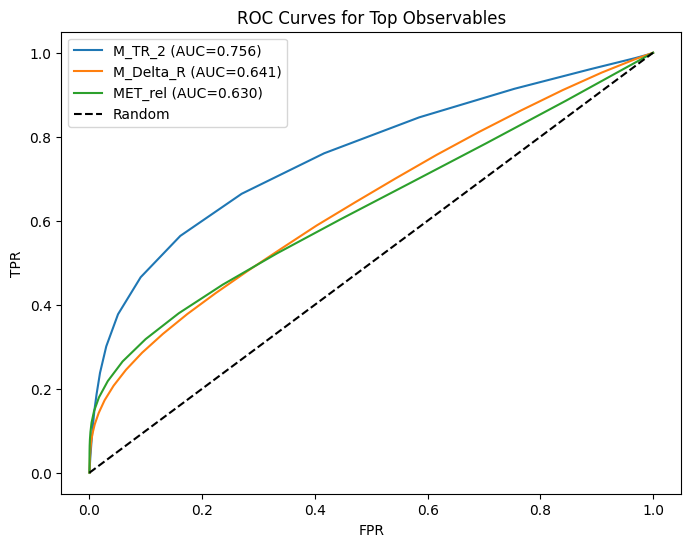

In [38]:
# I compare the top observables I identified earlier.
top_observables = ["M_TR_2", "M_Delta_R", "MET_rel"]
plot_roc_curves(df_sig, df_bkg, top_observables, title="ROC Curves for Top Observables")


The ROC curve shows how well each observable separates signal from background. A curve closer to the top-left corner means better separation. The AUC summarizes the curve in one number, where a value closer to 1 means stronger discrimination.

In [39]:
def plot_roc_after_each_cut(df_sig, df_bkg, cuts, obs_name, bins=100, title="ROC after selections"):
    """Plot the ROC curve for one observable after each successive selection."""
    
    sig_now = df_sig.copy()
    bkg_now = df_bkg.copy()
    plt.figure(figsize=(8, 6))
    
    # I include the starting point before any cuts.
    TPR, FPR, cut_values = compute_tpr_fpr(sig_now, bkg_now, obs_name, bins=bins)
    plt.plot(FPR, TPR, label=f"No cuts (AUC={compute_auc(TPR, FPR):.3f})")
    
    # I apply each cut one by one and redraw the ROC curve on the remaining events.
    for obs, xc in cuts:
        sig_now = sig_now[sig_now[obs] > xc]
        bkg_now = bkg_now[bkg_now[obs] > xc]
        
        if len(sig_now) == 0 or len(bkg_now) == 0:
            break
        
        TPR, FPR, cut_values = compute_tpr_fpr(sig_now, bkg_now, obs_name, bins=bins)
        plt.plot(FPR, TPR, label=f"After {obs}>{xc:.3f} (AUC={compute_auc(TPR, FPR):.3f})")
    
    plt.plot([0, 1], [0, 1], "k--", label="Random")
    plt.xlabel("FPR")
    plt.ylabel("TPR")
    plt.title(title)
    plt.legend()
    plt.show()


C:\Users\Renuka\AppData\Local\Temp\ipykernel_9024\3062002494.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(TPR_sorted, FPR_sorted)


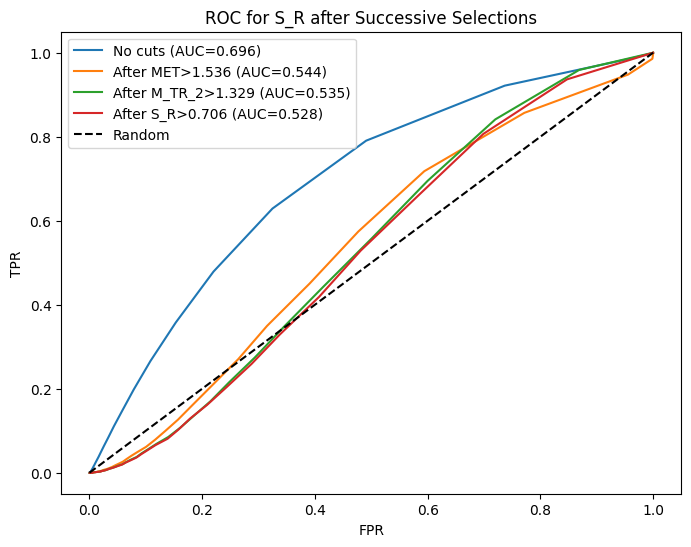

In [40]:
# I use scenario 2 as an example to show how the ROC curve changes after successive cuts.
example_cuts = cuts_by_scenario["2"]
plot_roc_after_each_cut(df_sig, df_bkg, example_cuts, "S_R",
                        title="ROC for S_R after Successive Selections")


C:\Users\Renuka\AppData\Local\Temp\ipykernel_9024\3062002494.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(TPR_sorted, FPR_sorted)


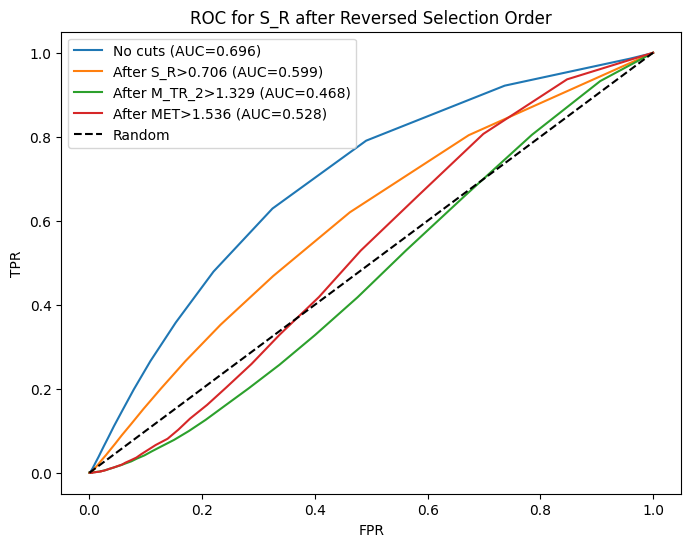

In [41]:
# I reverse the cut order to demonstrate that the order can change the remaining sample.
reversed_cuts = list(reversed(example_cuts))
plot_roc_after_each_cut(df_sig, df_bkg, reversed_cuts, "S_R",
                        title="ROC for S_R after Reversed Selection Order")


When I change the order of the selections, the intermediate ROC curves can change because each cut leaves behind a different subset of events. This matches the correlation result: when variables are related, one cut affects the distribution of the next variable.

## Exercise 8: Linear Discriminant

### Exercise 8.1

Using numpy, compute the between-class $\bf{S}_B$ and within-class $\bf{S}_W$ covariance matrices defined as:

$$
\bf{S}_B = (\bf{m_2}-\bf{m_1})(\bf{m_2}-\bf{m_1})^T \\
$$
$$
\bf{S}_W = \sum_{i=1,2} \sum_{n=1}^{l_i} (\bf{x}_n^i - \bf{m}_i) (\bf{x}_n^i - \bf{m}_i)^T
$$

where $\bf{m_i}$ are the vectors containing the means for category 1 and 2, here defined as signal and background. Here $\bf{x}_n^i$ is the vector containing the observables for the $n$th example event in category $i$.

### Exercise 8.1

Compute the linear coefficients $\bf{w} = \bf{S_W}^{-1}(\bf{m_2}-\bf{m_1})$. Compare the histogram of the distribution of $F_n^i=\bf{w}^T\bf{x}_n^i$ for the two categories.

### Exercise 8.1

Draw the ROC curve for $F_n$. 

### Exercise 8.1

What is the maximal significance you can obtain in the scenarios in exercise 5? 

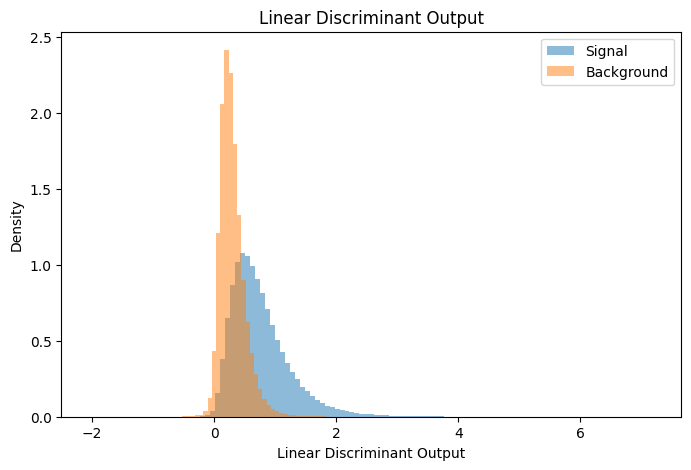

In [42]:
# I remove the label column because the linear discriminant should only use observables.
disc_vars = VarNames[1:]
X_sig = df_sig[disc_vars].to_numpy()
X_bkg = df_bkg[disc_vars].to_numpy()

# I compute the mean vector for each class.
m_sig = np.mean(X_sig, axis=0)
m_bkg = np.mean(X_bkg, axis=0)

# I compute the between-class scatter matrix S_B.
# This measures how far apart the two class means are.
delta_mean = (m_sig - m_bkg).reshape(-1, 1)
S_B = delta_mean @ delta_mean.T

# I compute the within-class scatter matrix S_W.
# This measures how spread out each class is around its own mean.
X_sig_centered = X_sig - m_sig
X_bkg_centered = X_bkg - m_bkg
S_W = X_sig_centered.T @ X_sig_centered + X_bkg_centered.T @ X_bkg_centered

# I use the pseudo-inverse instead of a direct inverse because it is more stable numerically.
w = np.linalg.pinv(S_W) @ (m_sig - m_bkg)

# I normalize the weight vector so the output scale is easier to read.
w = w / np.linalg.norm(w)

# I project each event onto the linear discriminant direction.
output_s = X_sig @ w
output_b = X_bkg @ w

# I flip the sign if needed so signal tends to have larger LD values than background.
# This matches the x > x_c cut strategy used earlier.
if np.mean(output_s) < np.mean(output_b):
    w = -w
    output_s = -output_s
    output_b = -output_b

# I compare the linear discriminant output for signal and background.
plt.figure(figsize=(8, 5))
plt.hist(output_s, bins=100, alpha=0.5, density=True, label="Signal")
plt.hist(output_b, bins=100, alpha=0.5, density=True, label="Background")
plt.xlabel("Linear Discriminant Output")
plt.ylabel("Density")
plt.title("Linear Discriminant Output")
plt.legend()
plt.show()


I used the linear discriminant to combine all observables into one new variable. The idea is to choose weights that separate the signal mean from the background mean while accounting for the spread inside each class. The histogram lets me compare whether this combined variable separates signal and background better than individual observables.

C:\Users\Renuka\AppData\Local\Temp\ipykernel_9024\3062002494.py:8: DeprecationWarning: `trapz` is deprecated. Use `trapezoid` instead, or one of the numerical integration functions in `scipy.integrate`.
  return np.trapz(TPR_sorted, FPR_sorted)


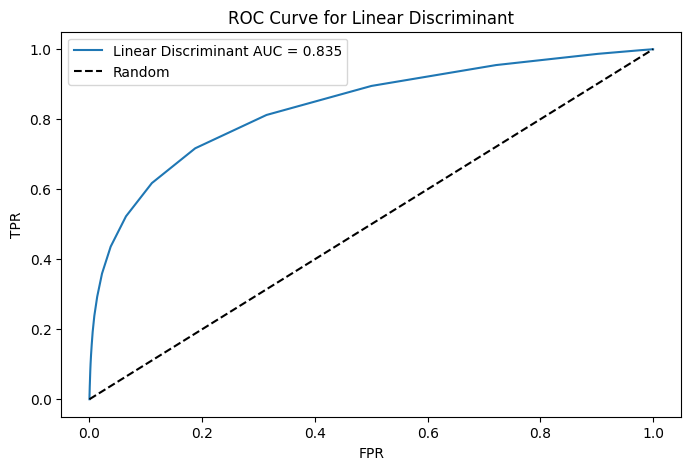

In [43]:
# I draw the ROC curve for the linear discriminant output.
ld_bins = np.histogram_bin_edges(np.concatenate([output_s, output_b]), bins=100)
TPR_ld, bins_ld = compute_rate(output_s, bins=ld_bins)
FPR_ld, bins_ld = compute_rate(output_b, bins=ld_bins)
auc_ld = compute_auc(TPR_ld, FPR_ld)

plt.figure(figsize=(8, 5))
plt.plot(FPR_ld, TPR_ld, label=f"Linear Discriminant AUC = {auc_ld:.3f}")
plt.plot([0, 1], [0, 1], "k--", label="Random")
plt.xlabel("FPR")
plt.ylabel("TPR")
plt.title("ROC Curve for Linear Discriminant")
plt.legend()
plt.show()


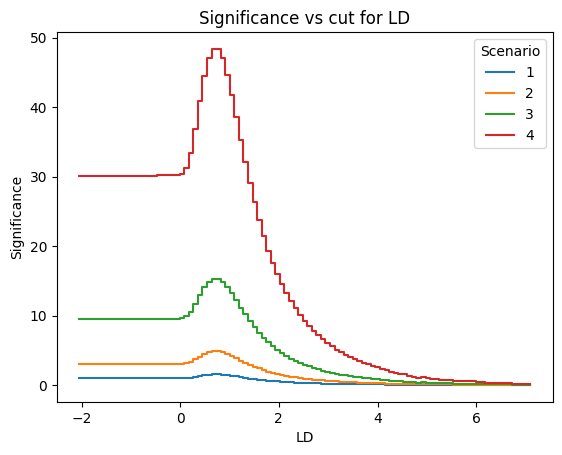

Scenario,N_S,N_B,TPR,FPR,N_S',N_B',sig,x_c
1,10,100,0.4361,0.0376,4.3606,3.7647,1.5298,0.7275
2,100,1000,0.4361,0.0376,43.6062,37.6466,4.8376,0.7275
3,1000,10000,0.4361,0.0376,436.0619,376.4658,15.2978,0.7275
4,10000,100000,0.4361,0.0376,4360.6186,3764.6581,48.3759,0.7275


[('1',
  10,
  100,
  np.float64(0.43606185522039737),
  np.float64(0.037646580857232555),
  np.float64(4.360618552203974),
  np.float64(3.7646580857232554),
  np.float64(1.5297801455794047),
  np.float64(0.7275087304825862)),
 ('2',
  100,
  1000,
  np.float64(0.43606185522039737),
  np.float64(0.037646580857232555),
  np.float64(43.60618552203974),
  np.float64(37.64658085723256),
  np.float64(4.8375895793348835),
  np.float64(0.7275087304825862)),
 ('3',
  1000,
  10000,
  np.float64(0.43606185522039737),
  np.float64(0.037646580857232555),
  np.float64(436.0618552203974),
  np.float64(376.46580857232556),
  np.float64(15.297801455794048),
  np.float64(0.7275087304825862)),
 ('4',
  10000,
  100000,
  np.float64(0.43606185522039737),
  np.float64(0.037646580857232555),
  np.float64(4360.618552203974),
  np.float64(3764.6580857232557),
  np.float64(48.37589579334883),
  np.float64(0.7275087304825862))]

In [44]:
# I reuse my significance function by putting the LD output into small dataframes.
ld_sig = pd.DataFrame({"LD": output_s})
ld_bkg = pd.DataFrame({"LD": output_b})
compare_significance(ld_sig, ld_bkg, "LD", scenarios, bins=100)


The linear discriminant combines multiple observables into one score, so it can use information from several variables at the same time. Its ROC curve and significance scan show how well this combined score separates signal from background. The maximum significance for each scenario is the largest value reported in the LD significance table.